---
## 1. Initialization

Memuat seluruh library yang diperlukan dan mendefinisikan path direktori.  
Variabel path ditulis sebagai konstanta (UPPER_CASE) sesuai konvensi clean code.

In [122]:
import pandas as pd
import numpy as np
import os
import cv2
import hashlib
import shutil
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data_mentah').exists():
    PROJECT_ROOT = Path(r'c:\laragon\www\jivara\dataScience')

BASE_DIR = PROJECT_ROOT
RAW_ORIGINAL_DIR = BASE_DIR / 'data_mentah' / 'Data Gambar Makanan Indonesia'
EXTRA_IMBALANCE_DIR = (
    BASE_DIR
    / 'data_mentah'
    / 'Scraping Image Data Imbalance'
    / 'cookpad_images untuk roboflow'
)
RAW_AUGMENTED_DIR = BASE_DIR / 'data_output' / 'roboflow_augmented_raw'
RAW_DIR = RAW_ORIGINAL_DIR
OUTPUT_DIR = BASE_DIR / 'data_output'
YOLO_DIR = OUTPUT_DIR / 'yolo_dataset'
DOCS_DIR = OUTPUT_DIR / 'docs'

SPLIT_NAMES = ['train', 'valid', 'test']
YOLO_SPLIT_MAP = {'train': 'train', 'valid': 'val', 'test': 'test'}

DOCS_DIR.mkdir(parents=True, exist_ok=True)
for subdirectory in ['images/train', 'images/val', 'images/test',
                     'labels/train', 'labels/val', 'labels/test']:
    (YOLO_DIR / subdirectory).mkdir(parents=True, exist_ok=True)

print("Setup selesai.")
print(f"Project root        : {BASE_DIR}")
print(f"Raw original dataset: {RAW_ORIGINAL_DIR}")
print(f"Extra imbalance dir : {EXTRA_IMBALANCE_DIR}")


Setup selesai.
Project root        : c:\laragon\www\jivara\dataScience
Raw original dataset: c:\laragon\www\jivara\dataScience\data_mentah\Data Gambar Makanan Indonesia
Extra imbalance dir : c:\laragon\www\jivara\dataScience\data_mentah\Scraping Image Data Imbalance\cookpad_images untuk roboflow


---
## 2. Exploratory Data Analysis

### 2.1 Load dan Inspeksi Anotasi

Memuat file `_annotations.csv` dari setiap split (train/valid/test),  
lalu menggabungkannya menjadi satu DataFrame untuk analisis menyeluruh.

In [123]:
def load_annotations(raw_directory, split_names):
    """Memuat dan menggabungkan CSV anotasi dari semua split."""
    dataframes = []
    for split_name in split_names:
        csv_path = raw_directory / split_name / '_annotations.csv'
        annotations = pd.read_csv(csv_path)
        annotations['split'] = split_name
        dataframes.append(annotations)
    return pd.concat(dataframes, ignore_index=True)

annotations_all = load_annotations(RAW_DIR, SPLIT_NAMES)

for split_name in SPLIT_NAMES:
    split_data = annotations_all[annotations_all['split'] == split_name]
    unique_images = split_data['filename'].nunique()
    total_annotations = len(split_data)
    print(f"{split_name:>6}: {unique_images:>5} gambar, {total_annotations:>5} anotasi")

print(f"\nTotal kelas: {annotations_all['class'].nunique()}")
print(f"Daftar kelas: {sorted(annotations_all['class'].unique())}")

 train:  2770 gambar,  4535 anotasi
 valid:   680 gambar,  1109 anotasi
  test:   270 gambar,   478 anotasi

Total kelas: 29
Daftar kelas: ['Apel', 'Ayam Goreng', 'Bakso', 'Biskuit Choco Chips', 'Burger', 'Capcay', 'Donat', 'Ikan Goreng', 'Kentang Goreng', 'Kiwi', 'Mie Goreng', 'Nanas', 'Nasi Goreng', 'Nasi Putih', 'Nugget', 'Pempek', 'Pisang', 'Pizza', 'Rendang Sapi', 'Sate', 'Spaghetti', 'Steak', 'Stroberi', 'Tahu Goreng', 'Telur Goreng', 'Telur Rebus', 'Tempe Goreng', 'Terong Balado', 'Tumis Kangkung']


### 2.1.1 Menambahkan Data Cookpad untuk Kelas Imbalance

Folder `data_mentah/Scraping Image Data Imbalance/cookpad_images untuk roboflow`
berisi gambar tambahan yang sudah dipisahkan per nama class. Karena gambar
tambahan ini belum memiliki anotasi bounding box, setiap gambar diperlakukan
sebagai single-object image dan diberi bounding box penuh satu gambar.

Cell ini membuat dataset kerja baru di `data_output/roboflow_augmented_raw`,
menyalin data Roboflow asli, membagi gambar tambahan ke `train`, `valid`, dan
`test`, lalu memperbarui tabel anotasi untuk dipakai oleh cell berikutnya.
Data asli di `data_mentah/Data Gambar Makanan Indonesia` tidak diubah.


In [124]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}
EXTRA_SPLIT_RATIOS = {'train': 0.8, 'valid': 0.1, 'test': 0.1}
RANDOM_SEED = 42
CLASS_FOLDER_ALIASES = {
    'biskuit': 'biskuit choco chips',
    'ikan bakar': 'ikan goreng',
    'pisang goreng': 'pisang',
    'sate ayam': 'sate',
}


def normalize_class_name(value):
    # Samakan format nama class folder Cookpad dengan class Roboflow.
    text = str(value).lower().strip()
    for old, new in [('_', ' '), ('-', ' ')]:
        text = text.replace(old, new)
    return ' '.join(text.split())


def build_class_lookup(class_names):
    return {normalize_class_name(class_name): class_name for class_name in class_names}


def copy_original_dataset(source_dir, target_dir, split_names):
    # Buat salinan dataset Roboflow asli sebagai working directory.
    if target_dir.exists():
        shutil.rmtree(target_dir)

    for split_name in split_names:
        source_split = source_dir / split_name
        target_split = target_dir / split_name
        target_split.mkdir(parents=True, exist_ok=True)

        for source_file in source_split.iterdir():
            if source_file.is_file():
                shutil.copy2(source_file, target_split / source_file.name)


def split_extra_images(image_paths, split_ratios, random_seed):
    rng = np.random.default_rng(random_seed)
    shuffled_paths = list(image_paths)
    rng.shuffle(shuffled_paths)

    total_images = len(shuffled_paths)
    train_end = int(round(total_images * split_ratios['train']))
    valid_count = int(round(total_images * split_ratios['valid']))
    valid_end = min(train_end + valid_count, total_images)

    return {
        'train': shuffled_paths[:train_end],
        'valid': shuffled_paths[train_end:valid_end],
        'test': shuffled_paths[valid_end:],
    }


def collect_extra_image_rows(extra_dir, augmented_dir, class_lookup, split_ratios, random_seed):
    rows = []
    summary_rows = []
    skipped_classes = []

    for class_dir in sorted(extra_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        normalized_folder_name = normalize_class_name(class_dir.name)
        normalized_folder_name = CLASS_FOLDER_ALIASES.get(
            normalized_folder_name,
            normalized_folder_name,
        )
        if normalized_folder_name not in class_lookup:
            skipped_classes.append(class_dir.name)
            continue

        roboflow_class = class_lookup[normalized_folder_name]
        image_paths = [
            image_path
            for image_path in sorted(class_dir.rglob('*'))
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ]
        split_images = split_extra_images(
            image_paths=image_paths,
            split_ratios=split_ratios,
            random_seed=random_seed,
        )

        for split_name, split_paths in split_images.items():
            for image_path in split_paths:
                with Image.open(image_path) as image:
                    width, height = image.size

                safe_stem = image_path.stem.replace(' ', '_')
                output_name = f"cookpad_imbalance_{class_dir.name}_{safe_stem}{image_path.suffix.lower()}"
                destination = augmented_dir / split_name / output_name
                shutil.copy2(image_path, destination)

                rows.append(
                    {
                        'filename': output_name,
                        'width': width,
                        'height': height,
                        'class': roboflow_class,
                        'xmin': 0,
                        'ymin': 0,
                        'xmax': width,
                        'ymax': height,
                        'split': split_name,
                        'source': 'cookpad_imbalance_full_image_bbox',
                    }
                )

        summary_rows.append(
            {
                'folder_class': class_dir.name,
                'roboflow_class': roboflow_class,
                'total_images': len(image_paths),
                'train': len(split_images['train']),
                'valid': len(split_images['valid']),
                'test': len(split_images['test']),
            }
        )

    if skipped_classes:
        print("Folder class yang tidak cocok dengan class Roboflow:")
        for class_name in skipped_classes:
            print(f"  - {class_name}")

    return pd.DataFrame(rows), pd.DataFrame(summary_rows)


def write_augmented_annotations(original_annotations, extra_annotations, augmented_dir, split_names):
    augmented_annotations = pd.concat(
        [original_annotations.assign(source='roboflow_original'), extra_annotations],
        ignore_index=True,
    )

    for split_name in split_names:
        split_annotations = augmented_annotations[augmented_annotations['split'] == split_name]
        export_columns = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
        split_annotations[export_columns].to_csv(
            augmented_dir / split_name / '_annotations.csv',
            index=False,
        )

    return augmented_annotations


original_class_counts = annotations_all['class'].value_counts().sort_index()
class_lookup = build_class_lookup(annotations_all['class'].unique())

copy_original_dataset(
    source_dir=RAW_ORIGINAL_DIR,
    target_dir=RAW_AUGMENTED_DIR,
    split_names=SPLIT_NAMES,
)

extra_annotations, extra_image_summary = collect_extra_image_rows(
    extra_dir=EXTRA_IMBALANCE_DIR,
    augmented_dir=RAW_AUGMENTED_DIR,
    class_lookup=class_lookup,
    split_ratios=EXTRA_SPLIT_RATIOS,
    random_seed=RANDOM_SEED,
)

annotations_all = write_augmented_annotations(
    original_annotations=annotations_all,
    extra_annotations=extra_annotations,
    augmented_dir=RAW_AUGMENTED_DIR,
    split_names=SPLIT_NAMES,
)
RAW_DIR = RAW_AUGMENTED_DIR

after_class_counts = annotations_all['class'].value_counts().sort_index()
balance_comparison = (
    pd.DataFrame({'before': original_class_counts, 'after': after_class_counts})
    .fillna(0)
    .astype(int)
)
balance_comparison['added'] = balance_comparison['after'] - balance_comparison['before']
balance_comparison['change_pct'] = np.where(
    balance_comparison['before'] > 0,
    (balance_comparison['added'] / balance_comparison['before'] * 100).round(1),
    np.nan,
)

print(f"Dataset kerja augmented: {RAW_AUGMENTED_DIR}")
print(f"Total gambar tambahan  : {extra_annotations['filename'].nunique():,}")
print(f"Total anotasi awal     : {len(original_class_counts):,} kelas, {original_class_counts.sum():,} anotasi")
print(f"Total anotasi akhir    : {annotations_all['class'].nunique():,} kelas, {len(annotations_all):,} anotasi")

display(extra_image_summary)
display(balance_comparison[balance_comparison['added'] > 0].sort_values('added', ascending=False))


Dataset kerja augmented: c:\laragon\www\jivara\dataScience\data_output\roboflow_augmented_raw
Total gambar tambahan  : 907
Total anotasi awal     : 29 kelas, 6,122 anotasi
Total anotasi akhir    : 29 kelas, 7,029 anotasi


,folder_class,roboflow_class,total_images,train,valid,test
0,biskuit,Biskuit Choco Chips,80,64,8,8
1,capcay,Capcay,81,65,8,8
2,ikan_bakar,Ikan Goreng,80,64,8,8
3,mie_goreng,Mie Goreng,80,64,8,8
4,nasi_goreng,Nasi Goreng,79,63,8,8
5,nasi_putih,Nasi Putih,35,28,4,3
6,pempek,Pempek,80,64,8,8
7,pisang_goreng,Pisang,80,64,8,8
8,sate_ayam,Sate,80,64,8,8
9,telur_goreng,Telur Goreng,72,58,7,7


,before,after,added,change_pct
class,,,,
Capcay,24,105,81,337.5
Biskuit Choco Chips,79,159,80,101.3
Ikan Goreng,130,210,80,61.5
Mie Goreng,100,180,80,80.0
Pisang,142,222,80,56.3
Pempek,79,159,80,101.3
Terong Balado,152,232,80,52.6
Sate,65,145,80,123.1
Tumis Kangkung,101,181,80,79.2


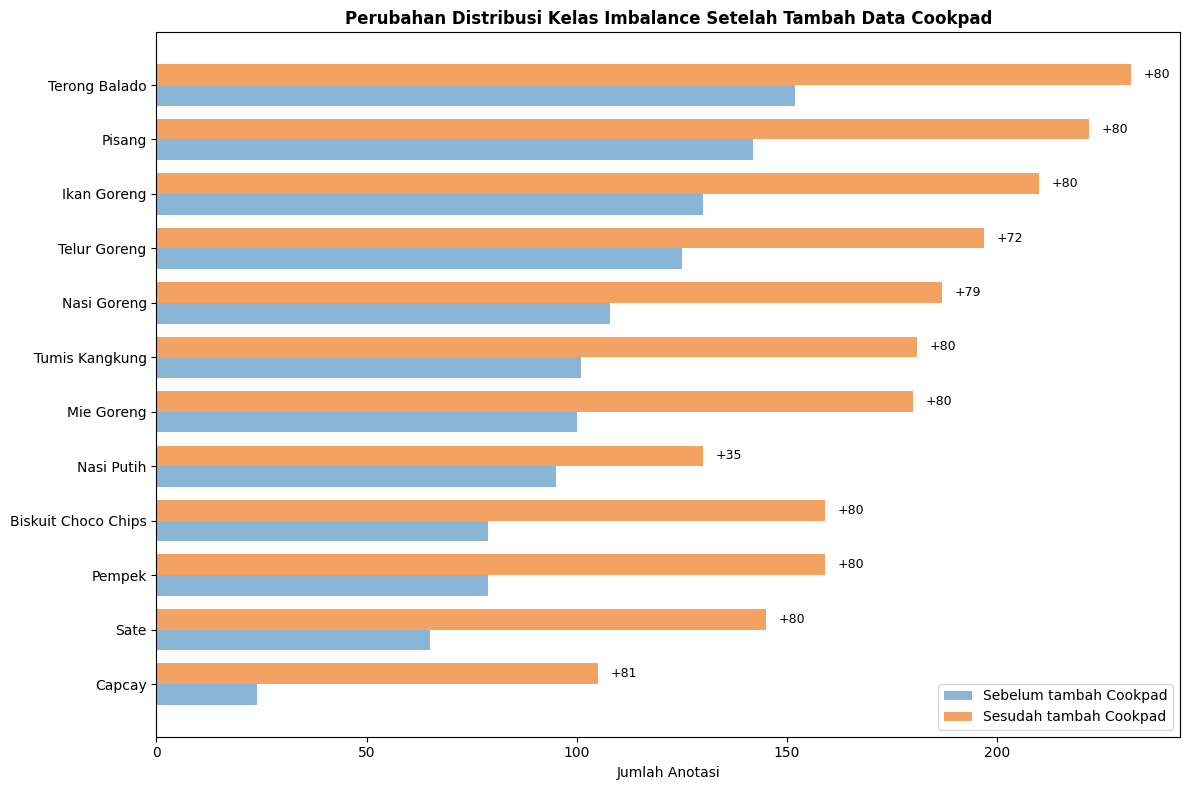

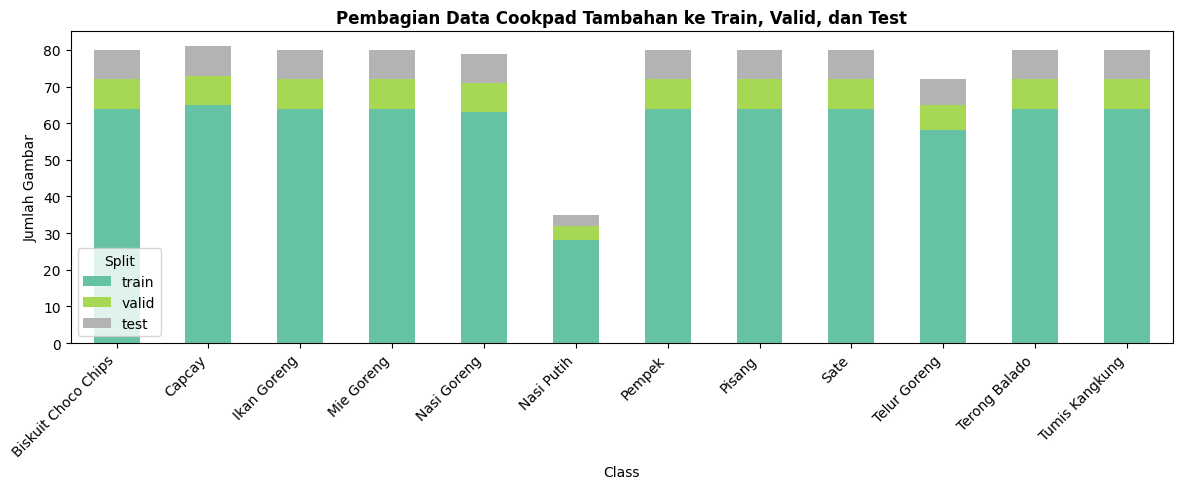

Ringkasan tambahan per split:


class,Biskuit Choco Chips,Capcay,Ikan Goreng,Mie Goreng,Nasi Goreng,Nasi Putih,Pempek,Pisang,Sate,Telur Goreng,Terong Balado,Tumis Kangkung
split,,,,,,,,,,,,
train,64,65,64,64,63,28,64,64,64,58,64,64
valid,8,8,8,8,8,4,8,8,8,7,8,8
test,8,8,8,8,8,3,8,8,8,7,8,8


In [125]:
classes_with_added_data = balance_comparison[balance_comparison['added'] > 0].index
plot_data = (
    balance_comparison.loc[classes_with_added_data, ['before', 'after']]
    .sort_values('before')
)

fig, ax = plt.subplots(figsize=(12, 8))
y_positions = np.arange(len(plot_data))
bar_height = 0.38

ax.barh(
    y_positions - bar_height / 2,
    plot_data['before'],
    height=bar_height,
    label='Sebelum tambah Cookpad',
    color='#8ab6d6',
)
ax.barh(
    y_positions + bar_height / 2,
    plot_data['after'],
    height=bar_height,
    label='Sesudah tambah Cookpad',
    color='#f4a261',
)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_data.index)
ax.set_xlabel('Jumlah Anotasi')
ax.set_title('Perubahan Distribusi Kelas Imbalance Setelah Tambah Data Cookpad', fontweight='bold')
ax.legend()

for index, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(row['after'] + 3, index + bar_height / 2, f"+{row['after'] - row['before']}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'imbalance_before_after_cookpad.png'), dpi=150, bbox_inches='tight')
plt.show()

split_addition_summary = (
    extra_annotations
    .groupby(['split', 'class'])
    .size()
    .unstack(fill_value=0)
    .reindex(SPLIT_NAMES)
)

fig, ax = plt.subplots(figsize=(12, 5))
split_addition_summary.T.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Pembagian Data Cookpad Tambahan ke Train, Valid, dan Test', fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Jumlah Gambar')
ax.legend(title='Split')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'imbalance_extra_split_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Ringkasan tambahan per split:")
display(split_addition_summary)


### 2.1.2 Menambahkan Data Cookpad 200 Extra

Folder `data_mentah/Scraping Image Data Imbalance/cookpad_images_200_extra` berisi tambahan gambar per class. Cell berikut hanya memasukkan folder yang nama class-nya cocok dengan class Roboflow, membagi gambar ke `train`, `valid`, dan `test`, lalu memperbarui tabel anotasi serta file `_annotations.csv` pada folder kerja augmented.

In [126]:
EXTRA_200_DIR = (
    BASE_DIR
    / 'data_mentah'
    / 'Scraping Image Data Imbalance'
    / 'cookpad_images_200_extra'
)
EXTRA_200_CLASS_ALIASES = {
    'sate umum': 'sate',
}
EXTRA_200_SOURCE = 'cookpad_200_extra_full_image_bbox'


def collect_cookpad_200_rows(extra_dir, augmented_dir, class_lookup, split_ratios, random_seed):
    rows = []
    summary_rows = []
    skipped_rows = []

    if not extra_dir.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {extra_dir}")

    for class_dir in sorted(extra_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        normalized_folder_name = normalize_class_name(class_dir.name)
        target_lookup_name = EXTRA_200_CLASS_ALIASES.get(
            normalized_folder_name,
            normalized_folder_name,
        )
        image_paths = [
            image_path
            for image_path in sorted(class_dir.rglob('*'))
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ]

        if target_lookup_name not in class_lookup:
            skipped_rows.append(
                {
                    'folder_class': class_dir.name,
                    'normalized_class': normalized_folder_name,
                    'target_class': target_lookup_name,
                    'total_images': len(image_paths),
                    'reason': 'target_class_not_found_in_roboflow',
                }
            )
            continue

        roboflow_class = class_lookup[target_lookup_name]
        split_images = split_extra_images(
            image_paths=image_paths,
            split_ratios=split_ratios,
            random_seed=random_seed,
        )

        for split_name, split_paths in split_images.items():
            for sequence, image_path in enumerate(split_paths, start=1):
                with Image.open(image_path) as image:
                    width, height = image.size

                safe_stem = image_path.stem.replace(' ', '_')
                output_name = (
                    f"cookpad_200_extra_{class_dir.name}_{sequence:04d}_{safe_stem}"
                    f"{image_path.suffix.lower()}"
                )
                destination = augmented_dir / split_name / output_name
                shutil.copy2(image_path, destination)

                rows.append(
                    {
                        'filename': output_name,
                        'width': width,
                        'height': height,
                        'class': roboflow_class,
                        'xmin': 0,
                        'ymin': 0,
                        'xmax': width,
                        'ymax': height,
                        'split': split_name,
                        'source': EXTRA_200_SOURCE,
                    }
                )

        summary_rows.append(
            {
                'folder_class': class_dir.name,
                'roboflow_class': roboflow_class,
                'total_images': len(image_paths),
                'train': len(split_images['train']),
                'valid': len(split_images['valid']),
                'test': len(split_images['test']),
            }
        )

    return pd.DataFrame(rows), pd.DataFrame(summary_rows), pd.DataFrame(skipped_rows)


before_200_annotations = annotations_all.copy()
before_200_class_counts = before_200_annotations['class'].value_counts().sort_index()

extra_200_annotations, extra_200_summary, skipped_extra_200_classes = collect_cookpad_200_rows(
    extra_dir=EXTRA_200_DIR,
    augmented_dir=RAW_AUGMENTED_DIR,
    class_lookup=class_lookup,
    split_ratios=EXTRA_SPLIT_RATIOS,
    random_seed=RANDOM_SEED,
)

annotations_all = pd.concat(
    [before_200_annotations, extra_200_annotations],
    ignore_index=True,
)

for split_name in SPLIT_NAMES:
    split_annotations = annotations_all[annotations_all['split'] == split_name]
    export_columns = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
    split_annotations[export_columns].to_csv(
        RAW_AUGMENTED_DIR / split_name / '_annotations.csv',
        index=False,
    )

RAW_DIR = RAW_AUGMENTED_DIR

after_200_class_counts = annotations_all['class'].value_counts().sort_index()
extra_200_balance_comparison = (
    pd.DataFrame({'before': before_200_class_counts, 'after': after_200_class_counts})
    .fillna(0)
    .astype(int)
)
extra_200_balance_comparison['added'] = (
    extra_200_balance_comparison['after'] - extra_200_balance_comparison['before']
)
extra_200_balance_comparison['change_pct'] = np.where(
    extra_200_balance_comparison['before'] > 0,
    (extra_200_balance_comparison['added'] / extra_200_balance_comparison['before'] * 100).round(1),
    np.nan,
)

print(f"Folder Cookpad 200 extra: {EXTRA_200_DIR}")
print(f"Total gambar tambahan   : {extra_200_annotations['filename'].nunique():,}")
print(f"Total anotasi sebelum   : {len(before_200_annotations):,}")
print(f"Total anotasi sesudah   : {len(annotations_all):,}")

print("Ringkasan folder yang masuk ke Roboflow:")
display(extra_200_summary)

if not skipped_extra_200_classes.empty:
    print("Folder yang dilewati karena tidak ada class Roboflow yang cocok:")
    display(skipped_extra_200_classes)

print("Perubahan class yang mendapat tambahan dari Cookpad 200 extra:")
display(
    extra_200_balance_comparison[extra_200_balance_comparison['added'] > 0]
    .sort_values('added', ascending=False)
)


Folder Cookpad 200 extra: c:\laragon\www\jivara\dataScience\data_mentah\Scraping Image Data Imbalance\cookpad_images_200_extra
Total gambar tambahan   : 869
Total anotasi sebelum   : 7,029
Total anotasi sesudah   : 7,898
Ringkasan folder yang masuk ke Roboflow:


,folder_class,roboflow_class,total_images,train,valid,test
0,apel,Apel,66,53,7,6
1,biskuit_choco_chips,Biskuit Choco Chips,251,201,25,25
2,capcay,Capcay,171,137,17,17
3,nasi_putih,Nasi Putih,46,37,5,4
4,nugget,Nugget,113,90,11,12
5,sate_umum,Sate,170,136,17,17
6,stroberi,Stroberi,52,42,5,5


Folder yang dilewati karena tidak ada class Roboflow yang cocok:


,folder_class,normalized_class,target_class,total_images,reason
0,asinan_jakarta,asinan jakarta,asinan jakarta,158,target_class_not_found_in_roboflow
1,ayam_betutu,ayam betutu,ayam betutu,136,target_class_not_found_in_roboflow
2,ayam_bumbu_rujak,ayam bumbu rujak,ayam bumbu rujak,139,target_class_not_found_in_roboflow
3,ayam_goreng_lengkuas,ayam goreng lengkuas,ayam goreng lengkuas,128,target_class_not_found_in_roboflow
4,bika_ambon,bika ambon,bika ambon,145,target_class_not_found_in_roboflow
5,bir_pletok,bir pletok,bir pletok,156,target_class_not_found_in_roboflow
6,bubur_manado,bubur manado,bubur manado,187,target_class_not_found_in_roboflow
7,cendol,cendol,cendol,102,target_class_not_found_in_roboflow
8,es_dawet,es dawet,es dawet,150,target_class_not_found_in_roboflow
9,gado_gado,gado gado,gado gado,197,target_class_not_found_in_roboflow


Perubahan class yang mendapat tambahan dari Cookpad 200 extra:


,before,after,added,change_pct
class,,,,
Biskuit Choco Chips,159,410,251,157.9
Capcay,105,276,171,162.9
Sate,145,315,170,117.2
Nugget,171,284,113,66.1
Apel,172,238,66,38.4
Stroberi,170,222,52,30.6
Nasi Putih,130,176,46,35.4


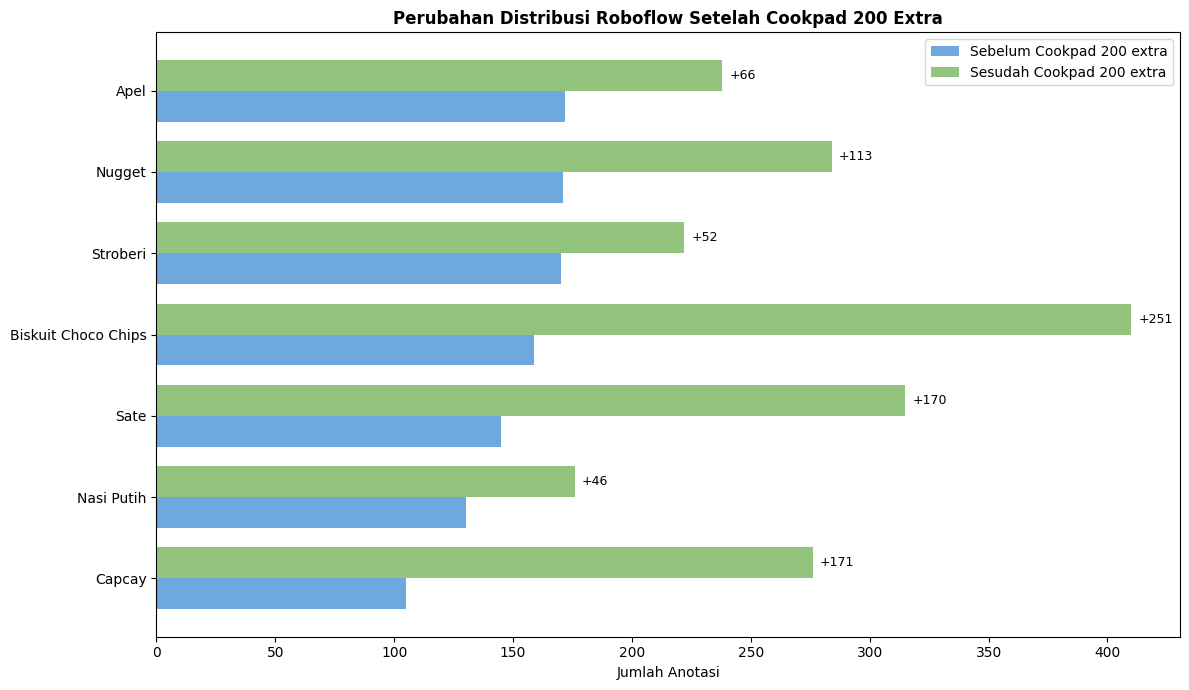

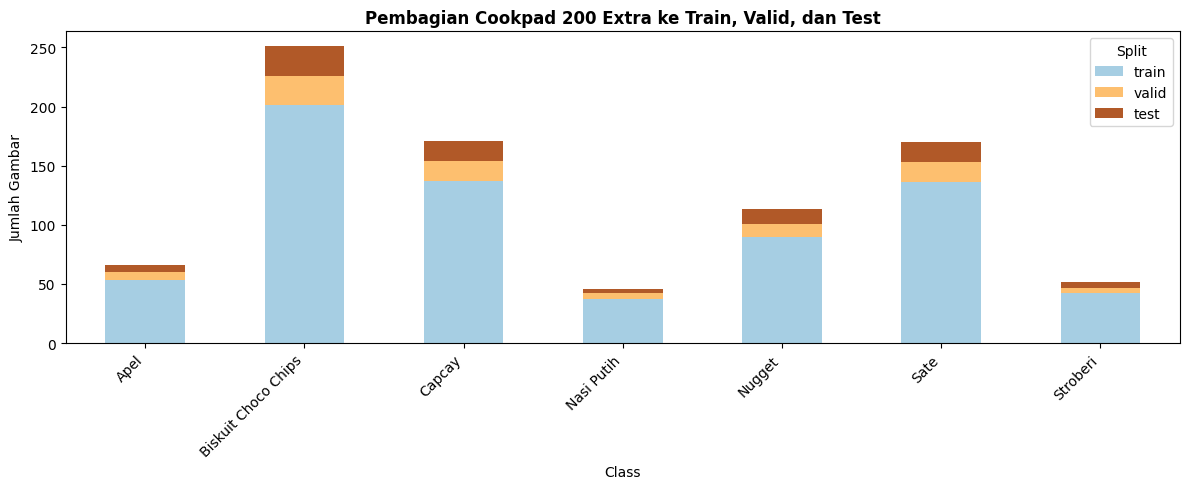

Ringkasan tambahan Cookpad 200 extra per split:


class,Apel,Biskuit Choco Chips,Capcay,Nasi Putih,Nugget,Sate,Stroberi
split,,,,,,,
train,53,201,137,37,90,136,42
valid,7,25,17,5,11,17,5
test,6,25,17,4,12,17,5


In [127]:
classes_with_200_additions = extra_200_balance_comparison[
    extra_200_balance_comparison['added'] > 0
].index
extra_200_plot_data = (
    extra_200_balance_comparison.loc[classes_with_200_additions, ['before', 'after']]
    .sort_values('before')
)

fig, ax = plt.subplots(figsize=(12, 7))
y_positions = np.arange(len(extra_200_plot_data))
bar_height = 0.38

ax.barh(
    y_positions - bar_height / 2,
    extra_200_plot_data['before'],
    height=bar_height,
    label='Sebelum Cookpad 200 extra',
    color='#6fa8dc',
)
ax.barh(
    y_positions + bar_height / 2,
    extra_200_plot_data['after'],
    height=bar_height,
    label='Sesudah Cookpad 200 extra',
    color='#93c47d',
)
ax.set_yticks(y_positions)
ax.set_yticklabels(extra_200_plot_data.index)
ax.set_xlabel('Jumlah Anotasi')
ax.set_title('Perubahan Distribusi Roboflow Setelah Cookpad 200 Extra', fontweight='bold')
ax.legend()

for index, (_, row) in enumerate(extra_200_plot_data.iterrows()):
    ax.text(row['after'] + 3, index + bar_height / 2, f"+{row['after'] - row['before']}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'roboflow_200_extra_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()

extra_200_split_summary = (
    extra_200_annotations
    .groupby(['split', 'class'])
    .size()
    .unstack(fill_value=0)
    .reindex(SPLIT_NAMES)
)

fig, ax = plt.subplots(figsize=(12, 5))
extra_200_split_summary.T.plot(kind='bar', stacked=True, ax=ax, colormap='Paired')
ax.set_title('Pembagian Cookpad 200 Extra ke Train, Valid, dan Test', fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Jumlah Gambar')
ax.legend(title='Split')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'roboflow_200_extra_split_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Ringkasan tambahan Cookpad 200 extra per split:")
display(extra_200_split_summary)


### 2.1.3 Menambahkan Roboflow Data Tambahan dan Deteksi Duplikasi

Folder `data_mentah/Scraping Image Data Imbalance/Roboflow data tambahan` berisi gambar tambahan untuk class Roboflow yang masih imbalance. Cell ini mendeteksi duplikasi exact-file dengan MD5 hash sebelum data dimasukkan, sehingga gambar duplikat tidak ditambahkan ulang ke tabel anotasi.

In [128]:
ROBOFLOW_EXTRA_DIR = (
    BASE_DIR
    / 'data_mentah'
    / 'Scraping Image Data Imbalance'
    / 'Roboflow data tambahan'
)
ROBOFLOW_EXTRA_SOURCE = 'roboflow_data_tambahan_full_image_bbox'
ROBOFLOW_EXTRA_CLASS_ALIASES = {
    'ikan goreang': 'ikan goreng',
    'spageti': 'spaghetti',
}


def md5_file_hash(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as file_handle:
        for chunk in iter(lambda: file_handle.read(8192), b''):
            hasher.update(chunk)
    return hasher.hexdigest()


def build_existing_image_hash_index(annotations, raw_dir):
    hash_index = {}
    image_rows = annotations[['filename', 'split']].drop_duplicates()

    for _, row in image_rows.iterrows():
        image_path = raw_dir / row['split'] / row['filename']
        if not image_path.exists():
            continue

        try:
            file_hash = md5_file_hash(image_path)
        except Exception:
            continue

        hash_index.setdefault(file_hash, []).append(
            {
                'filename': row['filename'],
                'split': row['split'],
                'path': str(image_path),
            }
        )

    return hash_index


def collect_roboflow_extra_rows_with_duplicate_check(
    extra_dir,
    augmented_dir,
    class_lookup,
    existing_hash_index,
    split_ratios,
    random_seed,
):
    rows = []
    summary_rows = []
    duplicate_rows = []
    skipped_rows = []
    new_hashes = {}

    if not extra_dir.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {extra_dir}")

    for class_dir in sorted(extra_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        normalized_folder_name = normalize_class_name(class_dir.name)
        target_lookup_name = ROBOFLOW_EXTRA_CLASS_ALIASES.get(
            normalized_folder_name,
            normalized_folder_name,
        )
        image_paths = [
            image_path
            for image_path in sorted(class_dir.rglob('*'))
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ]

        if target_lookup_name not in class_lookup:
            skipped_rows.append(
                {
                    'folder_class': class_dir.name,
                    'normalized_class': normalized_folder_name,
                    'target_class': target_lookup_name,
                    'total_images': len(image_paths),
                    'reason': 'target_class_not_found_in_roboflow',
                }
            )
            continue

        roboflow_class = class_lookup[target_lookup_name]
        unique_image_paths = []

        for image_path in image_paths:
            try:
                file_hash = md5_file_hash(image_path)
            except Exception as exc:
                duplicate_rows.append(
                    {
                        'folder_class': class_dir.name,
                        'target_class': roboflow_class,
                        'source_path': str(image_path),
                        'duplicate_reason': 'hash_read_error',
                        'duplicate_with': str(exc),
                    }
                )
                continue

            if file_hash in existing_hash_index:
                duplicate_rows.append(
                    {
                        'folder_class': class_dir.name,
                        'target_class': roboflow_class,
                        'source_path': str(image_path),
                        'duplicate_reason': 'already_in_augmented_dataset',
                        'duplicate_with': existing_hash_index[file_hash][0]['path'],
                    }
                )
                continue

            if file_hash in new_hashes:
                duplicate_rows.append(
                    {
                        'folder_class': class_dir.name,
                        'target_class': roboflow_class,
                        'source_path': str(image_path),
                        'duplicate_reason': 'duplicate_inside_new_batch',
                        'duplicate_with': new_hashes[file_hash],
                    }
                )
                continue

            new_hashes[file_hash] = str(image_path)
            unique_image_paths.append(image_path)

        split_images = split_extra_images(
            image_paths=unique_image_paths,
            split_ratios=split_ratios,
            random_seed=random_seed,
        )

        copied_count = 0
        unreadable_count = 0
        for split_name, split_paths in split_images.items():
            for sequence, image_path in enumerate(split_paths, start=1):
                try:
                    with Image.open(image_path) as image:
                        width, height = image.size
                        image.verify()
                except Exception as exc:
                    unreadable_count += 1
                    duplicate_rows.append(
                        {
                            'folder_class': class_dir.name,
                            'target_class': roboflow_class,
                            'source_path': str(image_path),
                            'duplicate_reason': 'unreadable_or_corrupt_image',
                            'duplicate_with': str(exc),
                        }
                    )
                    continue

                safe_stem = image_path.stem.replace(' ', '_')
                output_name = (
                    f"roboflow_data_tambahan_{class_dir.name}_{sequence:04d}_{safe_stem}"
                    f"{image_path.suffix.lower()}"
                )
                destination = augmented_dir / split_name / output_name
                shutil.copy2(image_path, destination)
                copied_count += 1

                rows.append(
                    {
                        'filename': output_name,
                        'width': width,
                        'height': height,
                        'class': roboflow_class,
                        'xmin': 0,
                        'ymin': 0,
                        'xmax': width,
                        'ymax': height,
                        'split': split_name,
                        'source': ROBOFLOW_EXTRA_SOURCE,
                    }
                )

        duplicate_count = sum(1 for item in duplicate_rows if item['folder_class'] == class_dir.name)
        summary_rows.append(
            {
                'folder_class': class_dir.name,
                'roboflow_class': roboflow_class,
                'total_images': len(image_paths),
                'unique_added': copied_count,
                'duplicates_or_invalid_skipped': duplicate_count,
                'train': len(split_images['train']),
                'valid': len(split_images['valid']),
                'test': len(split_images['test']),
            }
        )

    return pd.DataFrame(rows), pd.DataFrame(summary_rows), pd.DataFrame(duplicate_rows), pd.DataFrame(skipped_rows)


before_roboflow_extra_annotations = annotations_all.copy()
before_roboflow_extra_counts = before_roboflow_extra_annotations['class'].value_counts().sort_index()
existing_roboflow_hashes = build_existing_image_hash_index(
    annotations=before_roboflow_extra_annotations,
    raw_dir=RAW_AUGMENTED_DIR,
)

(
    roboflow_extra_annotations,
    roboflow_extra_summary,
    roboflow_extra_duplicates,
    roboflow_extra_skipped_classes,
) = collect_roboflow_extra_rows_with_duplicate_check(
    extra_dir=ROBOFLOW_EXTRA_DIR,
    augmented_dir=RAW_AUGMENTED_DIR,
    class_lookup=class_lookup,
    existing_hash_index=existing_roboflow_hashes,
    split_ratios=EXTRA_SPLIT_RATIOS,
    random_seed=RANDOM_SEED,
)

annotations_all = pd.concat(
    [before_roboflow_extra_annotations, roboflow_extra_annotations],
    ignore_index=True,
)

for split_name in SPLIT_NAMES:
    split_annotations = annotations_all[annotations_all['split'] == split_name]
    export_columns = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
    split_annotations[export_columns].to_csv(
        RAW_AUGMENTED_DIR / split_name / '_annotations.csv',
        index=False,
    )

RAW_DIR = RAW_AUGMENTED_DIR

after_roboflow_extra_counts = annotations_all['class'].value_counts().sort_index()
roboflow_extra_balance_comparison = (
    pd.DataFrame({'before': before_roboflow_extra_counts, 'after': after_roboflow_extra_counts})
    .fillna(0)
    .astype(int)
)
roboflow_extra_balance_comparison['added'] = (
    roboflow_extra_balance_comparison['after'] - roboflow_extra_balance_comparison['before']
)
roboflow_extra_balance_comparison['change_pct'] = np.where(
    roboflow_extra_balance_comparison['before'] > 0,
    (roboflow_extra_balance_comparison['added'] / roboflow_extra_balance_comparison['before'] * 100).round(1),
    np.nan,
)

print(f"Folder Roboflow data tambahan: {ROBOFLOW_EXTRA_DIR}")
print(f"Total gambar unik ditambahkan : {roboflow_extra_annotations['filename'].nunique():,}")
print(f"Total duplikat dilewati       : {len(roboflow_extra_duplicates):,}")
print(f"Total anotasi sebelum         : {len(before_roboflow_extra_annotations):,}")
print(f"Total anotasi sesudah         : {len(annotations_all):,}")

print("Ringkasan folder yang masuk ke Roboflow:")
display(roboflow_extra_summary)

if not roboflow_extra_skipped_classes.empty:
    print("Folder yang dilewati karena tidak ada class Roboflow yang cocok:")
    display(roboflow_extra_skipped_classes)

if not roboflow_extra_duplicates.empty:
    print("Contoh data duplikat yang dilewati:")
    display(roboflow_extra_duplicates.head(20))

print("Perubahan class yang mendapat tambahan Roboflow data tambahan:")
display(
    roboflow_extra_balance_comparison[roboflow_extra_balance_comparison['added'] > 0]
    .sort_values('added', ascending=False)
)


Folder Roboflow data tambahan: c:\laragon\www\jivara\dataScience\data_mentah\Scraping Image Data Imbalance\Roboflow data tambahan
Total gambar unik ditambahkan : 1,186
Total duplikat dilewati       : 55
Total anotasi sebelum         : 7,898
Total anotasi sesudah         : 9,084
Ringkasan folder yang masuk ke Roboflow:


,folder_class,roboflow_class,total_images,unique_added,duplicates_or_invalid_skipped,train,valid,test
0,bakso,Bakso,126,126,0,101,13,12
1,burger,Burger,110,110,0,88,11,11
2,Ikan_goreang,Ikan Goreng,54,54,0,43,5,6
3,mie_goreng,Mie Goreng,118,118,0,94,12,12
4,nanas,Nanas,76,75,1,61,8,7
5,nasi_goreng,Nasi Goreng,37,37,0,30,4,3
6,nasi_putih,Nasi Putih,189,136,53,109,14,13
7,pempek,Pempek,132,132,0,106,13,13
8,spageti,Spaghetti,135,135,0,108,14,13
9,Steak,Steak,49,49,0,39,5,5


Contoh data duplikat yang dilewati:


,folder_class,target_class,source_path,duplicate_reason,duplicate_with
0,nanas,Nanas,c:\laragon\www\jivara\dataScience\data_mentah\...,unreadable_or_corrupt_image,cannot identify image file 'c:\\laragon\\www\\...
1,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
2,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
3,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
4,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
5,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
6,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
7,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
8,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...
9,nasi_putih,Nasi Putih,c:\laragon\www\jivara\dataScience\data_mentah\...,already_in_augmented_dataset,c:\laragon\www\jivara\dataScience\data_output\...


Perubahan class yang mendapat tambahan Roboflow data tambahan:


,before,after,added,change_pct
class,,,,
Nasi Putih,176,312,136,77.3
Spaghetti,191,326,135,70.7
Pempek,159,291,132,83.0
Tumis Kangkung,181,310,129,71.3
Bakso,201,327,126,62.7
Mie Goreng,180,298,118,65.6
Burger,209,319,110,52.6
Telur Goreng,197,282,85,43.1
Nanas,174,249,75,43.1


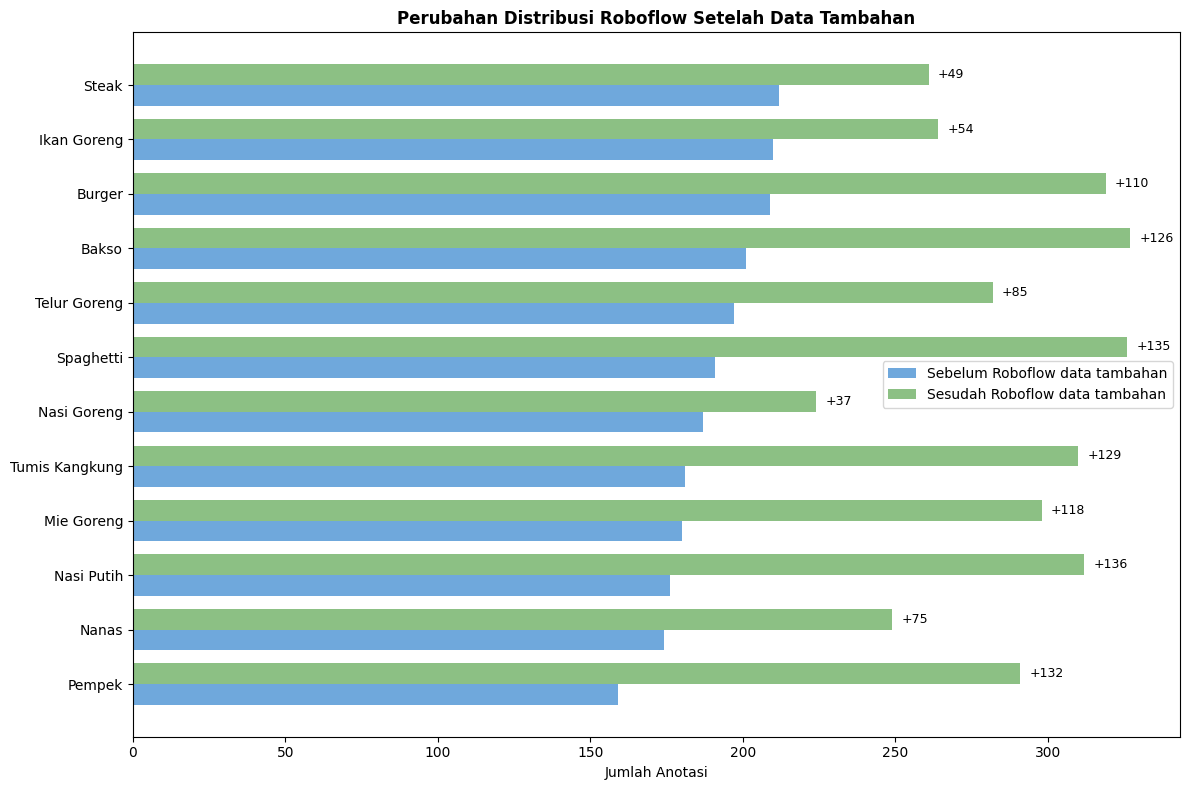

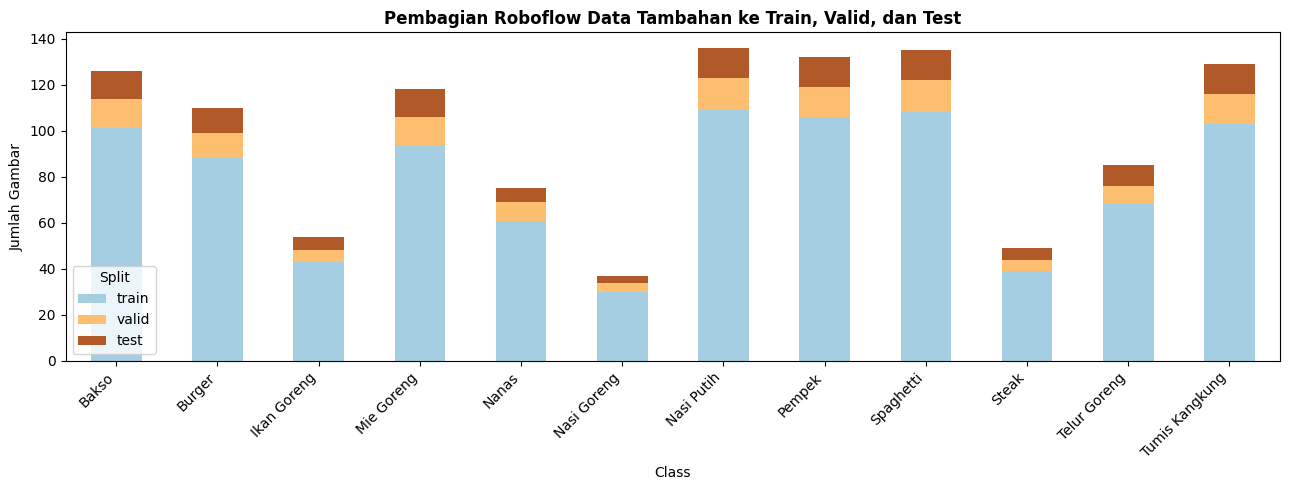

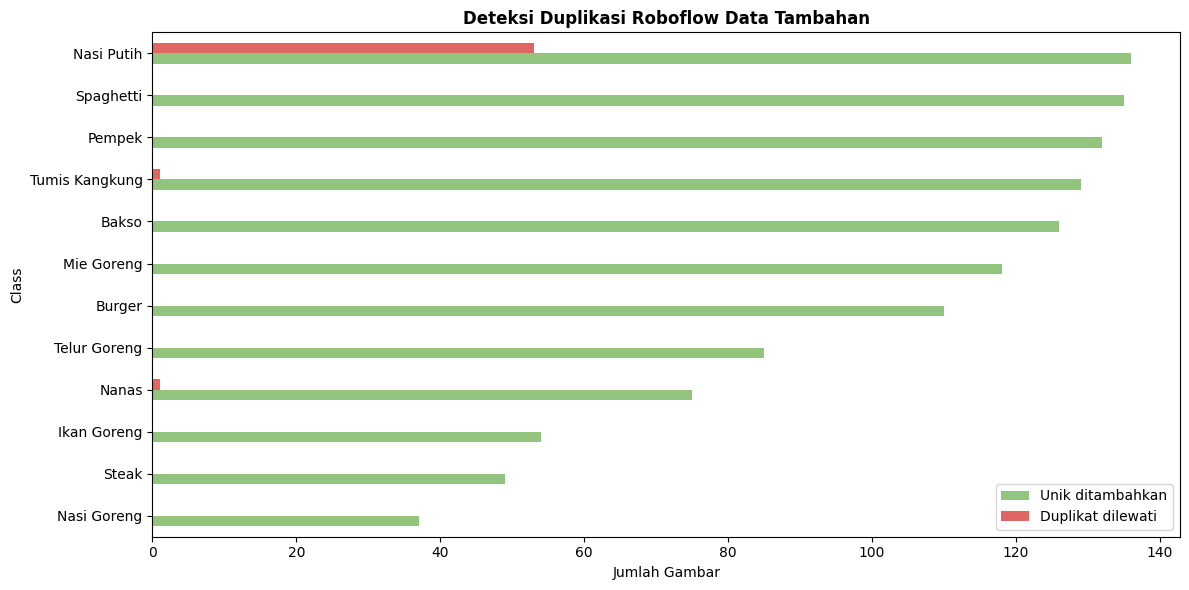

Ringkasan tambahan Roboflow data tambahan per split:


class,Bakso,Burger,Ikan Goreng,Mie Goreng,Nanas,Nasi Goreng,Nasi Putih,Pempek,Spaghetti,Steak,Telur Goreng,Tumis Kangkung
split,,,,,,,,,,,,
train,101,88,43,94,61,30,109,106,108,39,68,103
valid,13,11,5,12,8,4,14,13,14,5,8,13
test,12,11,6,12,6,3,13,13,13,5,9,13


In [129]:
classes_with_roboflow_extra = roboflow_extra_balance_comparison[
    roboflow_extra_balance_comparison['added'] > 0
].index
roboflow_extra_plot_data = (
    roboflow_extra_balance_comparison.loc[classes_with_roboflow_extra, ['before', 'after']]
    .sort_values('before')
)

fig, ax = plt.subplots(figsize=(12, 8))
y_positions = np.arange(len(roboflow_extra_plot_data))
bar_height = 0.38

ax.barh(
    y_positions - bar_height / 2,
    roboflow_extra_plot_data['before'],
    height=bar_height,
    label='Sebelum Roboflow data tambahan',
    color='#6fa8dc',
)
ax.barh(
    y_positions + bar_height / 2,
    roboflow_extra_plot_data['after'],
    height=bar_height,
    label='Sesudah Roboflow data tambahan',
    color='#8cc084',
)
ax.set_yticks(y_positions)
ax.set_yticklabels(roboflow_extra_plot_data.index)
ax.set_xlabel('Jumlah Anotasi')
ax.set_title('Perubahan Distribusi Roboflow Setelah Data Tambahan', fontweight='bold')
ax.legend()

for index, (_, row) in enumerate(roboflow_extra_plot_data.iterrows()):
    ax.text(row['after'] + 3, index + bar_height / 2, f"+{row['after'] - row['before']}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'roboflow_data_tambahan_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()

roboflow_extra_split_summary = (
    roboflow_extra_annotations
    .groupby(['split', 'class'])
    .size()
    .unstack(fill_value=0)
    .reindex(SPLIT_NAMES)
)

fig, ax = plt.subplots(figsize=(13, 5))
roboflow_extra_split_summary.T.plot(kind='bar', stacked=True, ax=ax, colormap='Paired')
ax.set_title('Pembagian Roboflow Data Tambahan ke Train, Valid, dan Test', fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Jumlah Gambar')
ax.legend(title='Split')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'roboflow_data_tambahan_split_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

duplicate_plot_data = (
    roboflow_extra_summary
    .set_index('roboflow_class')[['unique_added', 'duplicates_or_invalid_skipped']]
    .sort_values('unique_added')
)

fig, ax = plt.subplots(figsize=(12, 6))
duplicate_plot_data.plot(kind='barh', stacked=False, ax=ax, color=['#93c47d', '#e06666'])
ax.set_title('Deteksi Duplikasi Roboflow Data Tambahan', fontweight='bold')
ax.set_xlabel('Jumlah Gambar')
ax.set_ylabel('Class')
ax.legend(['Unik ditambahkan', 'Duplikat dilewati'])
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'roboflow_data_tambahan_duplicate_detection.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Ringkasan tambahan Roboflow data tambahan per split:")
display(roboflow_extra_split_summary)


### 2.2 Distribusi Kelas

Visualisasi jumlah anotasi per kelas untuk mengidentifikasi ketidakseimbangan (imbalance).  
Kelas dengan jumlah anotasi sangat sedikit berpotensi menghasilkan performa model yang rendah.

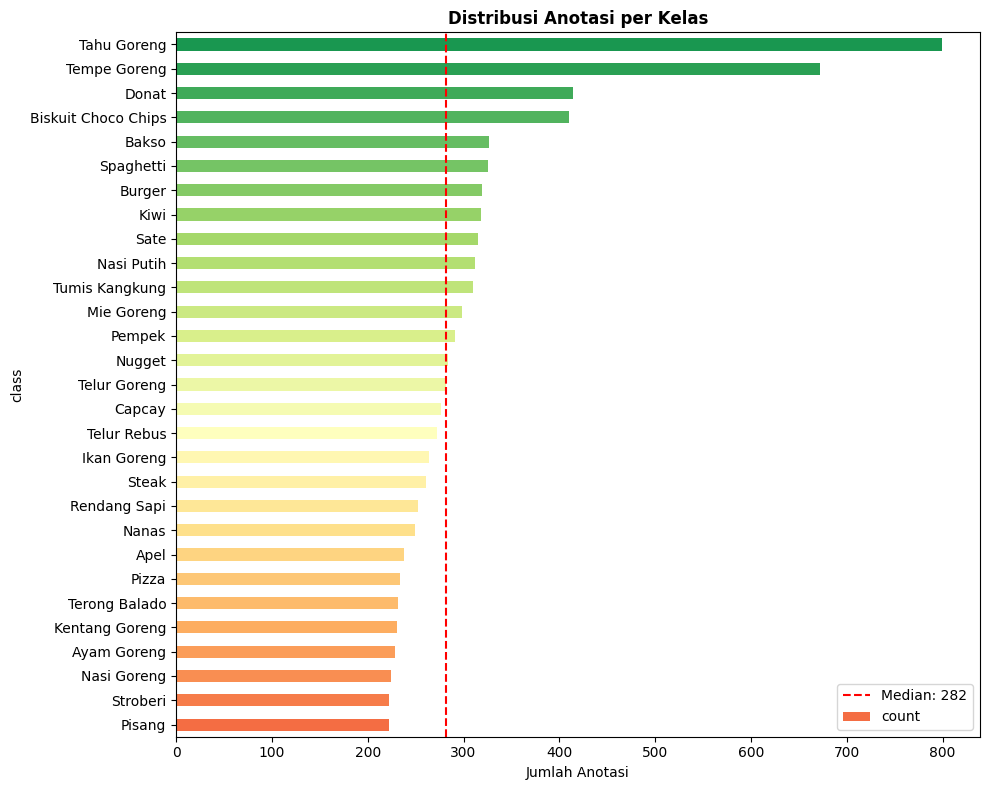

Imbalance ratio: 3.6x
Kelas terbanyak : Tahu Goreng (799)
Kelas tersedikit: Pisang (222)


In [130]:
class_counts = annotations_all['class'].value_counts().sort_values()
imbalance_ratio = class_counts.max() / class_counts.min()

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(class_counts)))
class_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Distribusi Anotasi per Kelas', fontweight='bold')
ax.set_xlabel('Jumlah Anotasi')
ax.axvline(x=class_counts.median(), color='red', linestyle='--', label=f'Median: {class_counts.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'docs' / 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {imbalance_ratio:.1f}x")
print(f"Kelas terbanyak : {class_counts.idxmax()} ({class_counts.max()})")
print(f"Kelas tersedikit: {class_counts.idxmin()} ({class_counts.min()})")

### 2.3 Analisis Bounding Box

Menganalisis properti bounding box: distribusi area, aspect ratio,  
dan jumlah objek per gambar. Informasi ini penting untuk menentukan  
parameter augmentasi dan ukuran input model.

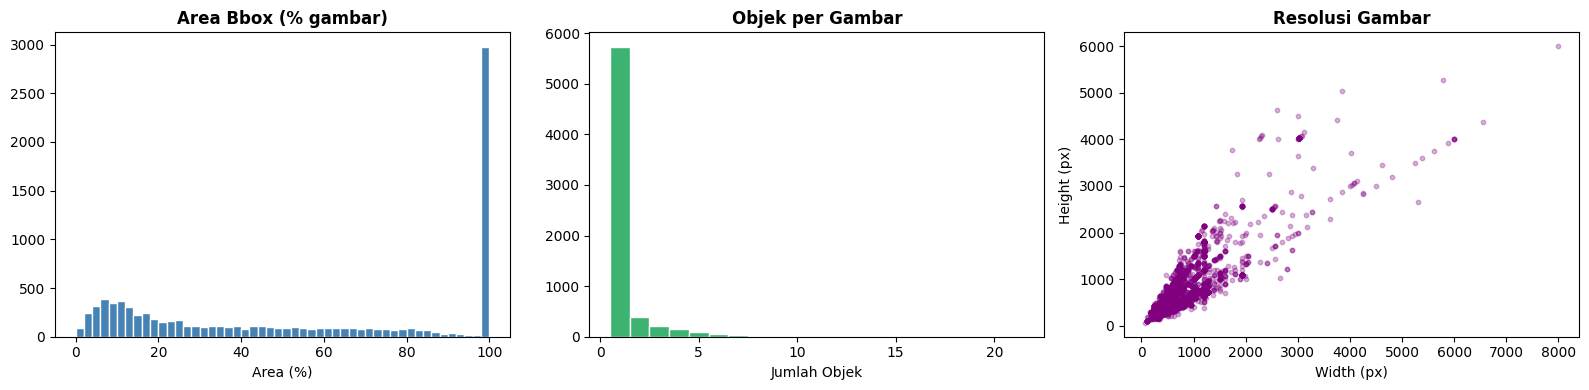

Rata-rata area bbox : 55.0%
Objek per gambar    : min=1, max=21, mean=1.4


In [131]:
annotations_all['bbox_width'] = annotations_all['xmax'] - annotations_all['xmin']
annotations_all['bbox_height'] = annotations_all['ymax'] - annotations_all['ymin']
annotations_all['bbox_area_pct'] = (
    (annotations_all['bbox_width'] * annotations_all['bbox_height'])
    / (annotations_all['width'] * annotations_all['height']) * 100
)
objects_per_image = annotations_all.groupby('filename').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(annotations_all['bbox_area_pct'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Area Bbox (% gambar)', fontweight='bold')
axes[0].set_xlabel('Area (%)')

axes[1].hist(objects_per_image.values, bins=range(1, objects_per_image.max() + 2),
             color='mediumseagreen', edgecolor='white', align='left')
axes[1].set_title('Objek per Gambar', fontweight='bold')
axes[1].set_xlabel('Jumlah Objek')

image_sizes = annotations_all.groupby('filename')[['width', 'height']].first()
axes[2].scatter(image_sizes['width'], image_sizes['height'], alpha=0.3, s=10, c='purple')
axes[2].set_title('Resolusi Gambar', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'docs' / 'eda_bbox_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Rata-rata area bbox : {annotations_all['bbox_area_pct'].mean():.1f}%")
print(f"Objek per gambar    : min={objects_per_image.min()}, max={objects_per_image.max()}, mean={objects_per_image.mean():.1f}")

---
## 3. Data Cleaning

### 3.1 Hapus Bounding Box yang Tidak Valid

Bounding box dianggap tidak valid apabila `xmin >= xmax` atau `ymin >= ymax`,  
karena menghasilkan area nol atau negatif yang akan menyebabkan error saat training.

In [132]:
def find_invalid_bboxes(annotations):
    """Identifikasi baris dengan bounding box tidak valid."""
    invalid_mask = (
        (annotations['xmin'] >= annotations['xmax'])
        | (annotations['ymin'] >= annotations['ymax'])
    )
    return invalid_mask

invalid_mask = find_invalid_bboxes(annotations_all)
invalid_rows = annotations_all[invalid_mask]

print(f"Bounding box tidak valid: {len(invalid_rows)}")
if len(invalid_rows) > 0:
    print(invalid_rows[['filename', 'class', 'xmin', 'ymin', 'xmax', 'ymax']].to_string(index=False))

annotations_clean = annotations_all[~invalid_mask].copy()
print(f"\nSisa anotasi setelah cleaning: {len(annotations_clean)}")

Bounding box tidak valid: 2
                                               filename        class  xmin  ymin  xmax  ymax
download-4-_jpg.rf.acc434d8468c6e1d3166ce9167733cf4.jpg Telur Goreng   222   163   223   163
 donuts_599_jpg.rf.bcc7fd9ef1741defc28f92307681c1da.jpg        Donat    21    53    23    53

Sisa anotasi setelah cleaning: 9082


### 3.2 Validasi Integritas Gambar

Memastikan setiap file gambar yang direferensikan dalam CSV benar-benar ada  
dan dapat dibuka tanpa error (tidak corrupt atau terpotong).

In [133]:
def validate_image_integrity(annotations, raw_directory):
    """Periksa apakah semua gambar dapat dibuka tanpa error."""
    corrupt_files = []
    valid_count = 0

    for split_name in annotations['split'].unique():
        split_dir = raw_directory / split_name
        image_files = annotations[annotations['split'] == split_name]['filename'].unique()

        for image_file in image_files:
            image_path = split_dir / image_file
            if not image_path.exists():
                corrupt_files.append(image_file)
                continue
            try:
                img = Image.open(image_path)
                img.verify()
                valid_count += 1
            except Exception:
                corrupt_files.append(image_file)

    return valid_count, corrupt_files

valid_count, corrupt_files = validate_image_integrity(annotations_clean, RAW_DIR)
print(f"Gambar valid  : {valid_count}")
print(f"Gambar corrupt: {len(corrupt_files)}")

if corrupt_files:
    annotations_clean = annotations_clean[~annotations_clean['filename'].isin(corrupt_files)]

Gambar valid  : 6574
Gambar corrupt: 108


### 3.3 Deteksi Duplikat Gambar

Menggunakan MD5 hash untuk mendeteksi file gambar yang identik secara binary.  
Duplikat antar split dapat menyebabkan data leakage.

In [134]:
def compute_file_hash(filepath):
    """Hitung MD5 hash dari sebuah file."""
    hasher = hashlib.md5()
    with open(filepath, 'rb') as file_handle:
        for chunk in iter(lambda: file_handle.read(8192), b''):
            hasher.update(chunk)
    return hasher.hexdigest()

def find_duplicate_images(annotations, raw_directory):
    """Identifikasi gambar duplikat berdasarkan hash."""
    hash_registry = {}
    duplicates = []

    for split_name in annotations['split'].unique():
        split_dir = raw_directory / split_name
        image_files = annotations[annotations['split'] == split_name]['filename'].unique()

        for image_file in image_files:
            image_path = split_dir / image_file
            if not image_path.exists():
                continue
            file_hash = compute_file_hash(image_path)
            if file_hash in hash_registry:
                duplicates.append((split_name, image_file, hash_registry[file_hash]))
            else:
                hash_registry[file_hash] = (split_name, image_file)

    return duplicates

duplicate_images = find_duplicate_images(annotations_clean, RAW_DIR)
print(f"Duplikat ditemukan: {len(duplicate_images)}")

Duplikat ditemukan: 197


### 3.4 Ringkasan Cleaning

In [135]:
print("Ringkasan setelah cleaning:")
for split_name in SPLIT_NAMES:
    split_data = annotations_clean[annotations_clean['split'] == split_name]
    print(f"  {split_name:>6}: {split_data['filename'].nunique()} gambar, {len(split_data)} anotasi")
print(f"  Total : {annotations_clean['filename'].nunique()} gambar, {len(annotations_clean)} anotasi")

Ringkasan setelah cleaning:
   train: 5037 gambar, 6539 anotasi
   valid: 978 gambar, 1407 anotasi
    test: 559 gambar, 756 anotasi
  Total : 6574 gambar, 8702 anotasi


---
## 4. Data Wrangling — Konversi ke Format YOLO

### 4.1 Class Mapping

Membuat pemetaan nama kelas ke integer ID (urut alfabetis).  
YOLO membutuhkan class ID numerik, bukan string.

In [136]:
class_names = sorted(annotations_clean['class'].unique())
class_to_id = {name: idx for idx, name in enumerate(class_names)}

print(f"Total kelas: {len(class_names)}\n")
for class_name, class_id in class_to_id.items():
    count = len(annotations_clean[annotations_clean['class'] == class_name])
    print(f"  {class_id:>2} -> {class_name} ({count})")

Total kelas: 29

   0 -> Apel (238)
   1 -> Ayam Goreng (229)
   2 -> Bakso (327)
   3 -> Biskuit Choco Chips (410)
   4 -> Burger (319)
   5 -> Capcay (276)
   6 -> Donat (413)
   7 -> Ikan Goreng (264)
   8 -> Kentang Goreng (231)
   9 -> Kiwi (316)
  10 -> Mie Goreng (298)
  11 -> Nanas (249)
  12 -> Nasi Goreng (224)
  13 -> Nasi Putih (311)
  14 -> Nugget (284)
  15 -> Pempek (291)
  16 -> Pisang (221)
  17 -> Pizza (234)
  18 -> Rendang Sapi (244)
  19 -> Sate (315)
  20 -> Spaghetti (326)
  21 -> Steak (261)
  22 -> Stroberi (222)
  23 -> Tahu Goreng (661)
  24 -> Telur Goreng (281)
  25 -> Telur Rebus (272)
  26 -> Tempe Goreng (443)
  27 -> Terong Balado (232)
  28 -> Tumis Kangkung (310)


### 4.2 Konversi Bounding Box: TensorFlow CSV ke YOLO TXT

Format TensorFlow menggunakan koordinat absolut `(xmin, ymin, xmax, ymax)`.  
YOLO membutuhkan format normalized center `(class_id, x_center, y_center, width, height)`  
dimana semua nilai berada dalam rentang [0, 1].

In [137]:
def convert_to_yolo_format(xmin, ymin, xmax, ymax, image_width, image_height):
    """Konversi bbox absolut ke YOLO normalized center format."""
    xmin = max(0, min(xmin, image_width))
    xmax = max(0, min(xmax, image_width))
    ymin = max(0, min(ymin, image_height))
    ymax = max(0, min(ymax, image_height))

    x_center = ((xmin + xmax) / 2.0) / image_width
    y_center = ((ymin + ymax) / 2.0) / image_height
    bbox_width = (xmax - xmin) / image_width
    bbox_height = (ymax - ymin) / image_height

    return x_center, y_center, bbox_width, bbox_height


def export_yolo_dataset(annotations, class_mapping, raw_dir, yolo_dir, split_map):
    """Konversi dan export seluruh dataset ke format YOLO."""
    for split_name, yolo_split in split_map.items():
        split_annotations = annotations[annotations['split'] == split_name]
        source_dir = raw_dir / split_name
        image_destination = yolo_dir / 'images' / yolo_split
        label_destination = yolo_dir / 'labels' / yolo_split

        image_count = 0
        for filename, group in split_annotations.groupby('filename'):
            source_image = source_dir / filename
            if not source_image.exists():
                continue

            destination_image = image_destination / filename
            if not destination_image.exists():
                shutil.copy2(source_image, destination_image)
            image_count += 1

            label_lines = []
            for _, row in group.iterrows():
                x_c, y_c, b_w, b_h = convert_to_yolo_format(
                    row['xmin'], row['ymin'], row['xmax'], row['ymax'],
                    row['width'], row['height']
                )
                if all(0 <= v <= 1 for v in [x_c, y_c, b_w, b_h]) and b_w > 0 and b_h > 0:
                    class_id = class_mapping[row['class']]
                    label_lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {b_w:.6f} {b_h:.6f}")

            if label_lines:
                label_file = label_destination / (Path(filename).stem + '.txt')
                with open(label_file, 'w') as file_handle:
                    file_handle.write('\n'.join(label_lines))

        print(f"  {yolo_split}: {image_count} gambar diproses")

export_yolo_dataset(annotations_clean, class_to_id, RAW_DIR, YOLO_DIR, YOLO_SPLIT_MAP)

  train: 5037 gambar diproses
  val: 978 gambar diproses
  test: 559 gambar diproses


### 4.3 Generate data.yaml

File konfigurasi yang dibutuhkan Ultralytics YOLOv11 untuk membaca dataset.

In [138]:
data_config = {
    'path': str(YOLO_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_names),
    'names': class_names
}

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as file_handle:
    yaml.dump(data_config, file_handle, default_flow_style=False, sort_keys=False)

print(f"Tersimpan: {yaml_path}")
print(f"nc: {data_config['nc']}")

Tersimpan: c:\laragon\www\jivara\dataScience\data_output\yolo_dataset\data.yaml
nc: 29


---
## 5. Strategi Augmentasi

Mengidentifikasi kelas-kelas dengan jumlah sampel di bawah ambang minimum.  
Augmentasi dilakukan secara online oleh YOLOv11 saat training,  
sehingga tidak perlu membuat file augmented secara offline.

In [139]:
MINIMUM_SAMPLES_PER_CLASS = 100

train_annotations = annotations_clean[annotations_clean['split'] == 'train']
train_class_counts = train_annotations['class'].value_counts()

minority_classes = train_class_counts[train_class_counts < MINIMUM_SAMPLES_PER_CLASS]

print(f"Target minimum per kelas: {MINIMUM_SAMPLES_PER_CLASS}")
print(f"Kelas di bawah target   : {len(minority_classes)}\n")

for class_name, count in minority_classes.items():
    augmentation_factor = int(np.ceil(MINIMUM_SAMPLES_PER_CLASS / count))
    print(f"  {class_name}: {count} (perlu augmentasi {augmentation_factor}x)")

print("\nRekomendasi parameter training YOLOv11:")
print("  hsv_h=0.015, hsv_s=0.7, hsv_v=0.4")
print("  degrees=10.0, translate=0.1, scale=0.5")
print("  fliplr=0.5, mosaic=1.0, mixup=0.1")
print("  cos_lr=True, close_mosaic=10")

Target minimum per kelas: 100
Kelas di bawah target   : 0


Rekomendasi parameter training YOLOv11:
  hsv_h=0.015, hsv_s=0.7, hsv_v=0.4
  degrees=10.0, translate=0.1, scale=0.5
  fliplr=0.5, mosaic=1.0, mixup=0.1
  cos_lr=True, close_mosaic=10


---
### 5.1 Cleanup Duplikat Train

Cell ini membersihkan exact duplicate pada split `train` saja. File tidak dihapus permanen; gambar dan label duplikat dipindahkan ke folder quarantine agar bisa dikembalikan jika diperlukan.

Default `APPLY_DUPLICATE_QUARANTINE = False` untuk dry-run. Ubah ke `True` jika jumlah kandidat sudah masuk akal.

In [140]:
from collections import defaultdict

APPLY_DUPLICATE_QUARANTINE = True
DUPLICATE_QUARANTINE_DIR = OUTPUT_DIR / 'quarantine' / 'exact_train_duplicates'


def sha1_file(file_path):
    hasher = hashlib.sha1()
    with open(file_path, 'rb') as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
            hasher.update(chunk)
    return hasher.hexdigest()


def quarantine_exact_train_duplicates(yolo_dir, quarantine_dir, apply=False):
    image_dir = yolo_dir / 'images' / 'train'
    label_dir = yolo_dir / 'labels' / 'train'

    duplicate_groups = defaultdict(list)
    image_files = sorted(
        file_path for file_path in image_dir.iterdir()
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

    for image_file in image_files:
        duplicate_groups[sha1_file(image_file)].append(image_file)

    candidates = []
    for digest, group in duplicate_groups.items():
        if len(group) < 2:
            continue
        keep_file = sorted(group)[0]
        for duplicate_file in sorted(group)[1:]:
            candidates.append({
                'sha1': digest,
                'keep_file': keep_file,
                'duplicate_file': duplicate_file,
                'label_file': label_dir / f'{duplicate_file.stem}.txt',
            })

    moved_images = 0
    moved_labels = 0
    missing_labels = 0

    for item in candidates:
        duplicate_file = item['duplicate_file']
        label_file = item['label_file']
        image_destination = quarantine_dir / 'images' / 'train' / duplicate_file.name
        label_destination = quarantine_dir / 'labels' / 'train' / label_file.name

        if apply:
            image_destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(duplicate_file), str(image_destination))
        moved_images += 1

        if label_file.exists():
            if apply:
                label_destination.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(label_file), str(label_destination))
            moved_labels += 1
        else:
            missing_labels += 1

    mode = 'APPLIED' if apply else 'DRY RUN'
    print(f'Mode: {mode}')
    print(f'Train images scanned : {len(image_files)}')
    print(f'Duplicate candidates : {len(candidates)}')
    print(f"Images {'moved' if apply else 'to move'} : {moved_images}")
    print(f"Labels {'moved' if apply else 'to move'} : {moved_labels}")
    print(f'Missing labels       : {missing_labels}')
    print(f'Quarantine folder   : {quarantine_dir}')

    if not apply:
        print()
        print('Belum ada file yang berubah. Ubah APPLY_DUPLICATE_QUARANTINE = True untuk memindahkan kandidat.')

    return candidates


train_duplicate_candidates = quarantine_exact_train_duplicates(
    YOLO_DIR,
    DUPLICATE_QUARANTINE_DIR,
    apply=APPLY_DUPLICATE_QUARANTINE,
)


Mode: APPLIED
Train images scanned : 5088
Duplicate candidates : 126
Images moved : 126
Labels moved : 126
Missing labels       : 0
Quarantine folder   : c:\laragon\www\jivara\dataScience\data_output\quarantine\exact_train_duplicates


### 5.2 Distribusi Setelah Cleanup Duplikat

Visualisasi ini membaca file label YOLO aktual setelah proses quarantine duplikat. Jadi grafiknya mencerminkan distribusi dataset yang benar-benar akan dipakai training.

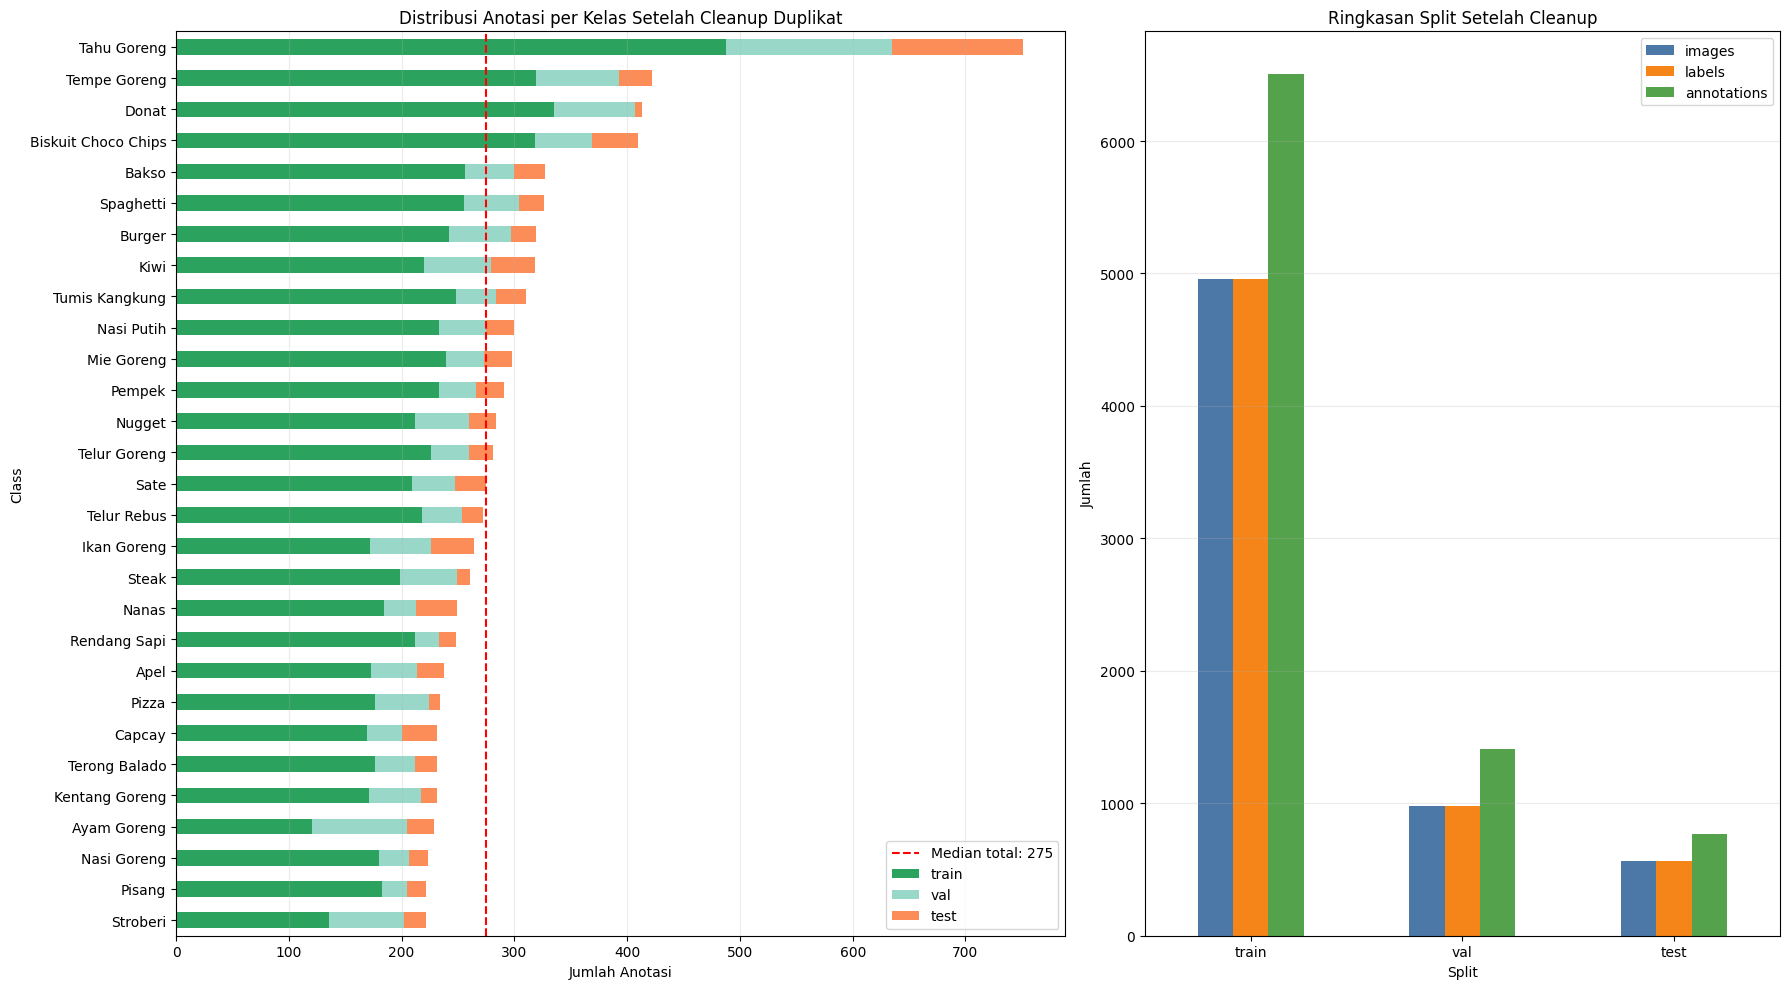

Ringkasan split setelah cleanup:


,images,labels,annotations
split,,,
train,4962,4962,6503
val,978,978,1407
test,562,562,770


Kelas terbesar setelah cleanup:


split,train,val,test,total
class,,,,
Tahu Goreng,488,147,116,751
Tempe Goreng,319,74,29,422
Donat,335,72,6,413
Biskuit Choco Chips,318,51,41,410
Bakso,256,44,27,327
Spaghetti,255,49,22,326
Burger,242,55,22,319
Kiwi,220,59,39,318
Tumis Kangkung,248,36,26,310


Kelas terkecil setelah cleanup:


split,train,val,test,total
class,,,,
Stroberi,136,66,20,222
Pisang,183,22,17,222
Nasi Goreng,180,27,16,223
Ayam Goreng,121,84,24,229
Kentang Goreng,171,46,14,231
Terong Balado,176,36,19,231
Capcay,169,31,31,231
Pizza,176,48,10,234
Apel,173,41,24,238


Plot tersimpan: c:\laragon\www\jivara\dataScience\data_output\docs\post_duplicate_cleanup_distribution.png


In [141]:
def count_yolo_annotations_by_split(yolo_dir, class_names):
    rows = []
    for split in ['train', 'val', 'test']:
        label_dir = yolo_dir / 'labels' / split
        class_counter = {class_name: 0 for class_name in class_names}
        image_counter = {class_name: set() for class_name in class_names}

        for label_file in label_dir.glob('*.txt'):
            with open(label_file) as file_handle:
                for line in file_handle:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    class_id = int(parts[0])
                    if 0 <= class_id < len(class_names):
                        class_name = class_names[class_id]
                        class_counter[class_name] += 1
                        image_counter[class_name].add(label_file.stem)

        for class_name in class_names:
            rows.append({
                'split': split,
                'class': class_name,
                'annotations': class_counter[class_name],
                'images_with_class': len(image_counter[class_name]),
            })

    return pd.DataFrame(rows)


post_cleanup_distribution = count_yolo_annotations_by_split(YOLO_DIR, class_names)
post_cleanup_pivot = (
    post_cleanup_distribution
    .pivot_table(index='class', columns='split', values='annotations', aggfunc='sum', fill_value=0)
    .reindex(columns=['train', 'val', 'test'])
)
post_cleanup_pivot['total'] = post_cleanup_pivot.sum(axis=1)
post_cleanup_pivot = post_cleanup_pivot.sort_values('total')

fig, axes = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [1.4, 1]})

post_cleanup_pivot[['train', 'val', 'test']].plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=['#2ca25f', '#99d8c9', '#fc8d59'],
)
axes[0].axvline(post_cleanup_pivot['total'].median(), color='red', linestyle='--', label=f"Median total: {post_cleanup_pivot['total'].median():.0f}")
axes[0].set_title('Distribusi Anotasi per Kelas Setelah Cleanup Duplikat')
axes[0].set_xlabel('Jumlah Anotasi')
axes[0].set_ylabel('Class')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.25)

split_counts = []
for split in ['train', 'val', 'test']:
    image_dir = YOLO_DIR / 'images' / split
    label_dir = YOLO_DIR / 'labels' / split
    image_count = sum(
        1 for path in image_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    label_count = len(list(label_dir.glob('*.txt')))
    annotation_count = int(post_cleanup_distribution[post_cleanup_distribution['split'] == split]['annotations'].sum())
    split_counts.append({'split': split, 'images': image_count, 'labels': label_count, 'annotations': annotation_count})

split_counts_df = pd.DataFrame(split_counts).set_index('split')
split_counts_df[['images', 'labels', 'annotations']].plot(kind='bar', ax=axes[1], color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_title('Ringkasan Split Setelah Cleanup')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
post_cleanup_plot_path = DOCS_DIR / 'post_duplicate_cleanup_distribution.png'
plt.savefig(post_cleanup_plot_path, dpi=160, bbox_inches='tight')
plt.show()

print('Ringkasan split setelah cleanup:')
display(split_counts_df)

print('Kelas terbesar setelah cleanup:')
display(post_cleanup_pivot.sort_values('total', ascending=False).head(10))

print('Kelas terkecil setelah cleanup:')
display(post_cleanup_pivot.sort_values('total').head(10))
print(f'Plot tersimpan: {post_cleanup_plot_path}')


### 5.3 Undersampling Class Mayoritas Train

Cell ini mengurangi class yang terlalu dominan hanya pada split `train`, terutama `Tahu Goreng` dan `Tempe Goreng`. File tidak dihapus permanen; gambar dan label dipindahkan ke quarantine.

Default `APPLY_UNDERSAMPLING = False` untuk dry-run. Ubah ke `True` kalau jumlah kandidat sudah sesuai.

In [142]:
APPLY_UNDERSAMPLING = True
UNDERSAMPLE_TARGETS = {
    'Tahu Goreng': 300,
    'Donat': 300,
    'Biskuit Choco Chips': 300,
    'Tempe Goreng': 300,
}
UNDERSAMPLE_QUARANTINE_DIR = OUTPUT_DIR / 'quarantine' / 'undersampled_train_majority_classes'


def read_yolo_label_rows(label_file):
    rows = []
    if not label_file.exists():
        return rows
    with open(label_file) as file_handle:
        for line in file_handle:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            rows.append((int(parts[0]), parts))
    return rows


def find_image_for_label(yolo_dir, split, stem):
    image_dir = yolo_dir / 'images' / split
    for extension in IMAGE_EXTENSIONS:
        candidate = image_dir / f'{stem}{extension}'
        if candidate.exists():
            return candidate
    return None


def get_train_label_inventory(yolo_dir, class_names):
    label_dir = yolo_dir / 'labels' / 'train'
    inventory = []
    class_counts = {class_name: 0 for class_name in class_names}

    for label_file in sorted(label_dir.glob('*.txt')):
        rows = read_yolo_label_rows(label_file)
        class_ids = [class_id for class_id, _ in rows]
        unique_class_ids = sorted(set(class_ids))
        for class_id in class_ids:
            if 0 <= class_id < len(class_names):
                class_counts[class_names[class_id]] += 1
        inventory.append({
            'label_file': label_file,
            'image_file': find_image_for_label(yolo_dir, 'train', label_file.stem),
            'class_ids': class_ids,
            'unique_class_ids': unique_class_ids,
            'annotation_count': len(class_ids),
        })

    return inventory, class_counts


def choose_undersampling_candidates(yolo_dir, class_names, targets):
    inventory, class_counts = get_train_label_inventory(yolo_dir, class_names)
    selected = []
    selected_stems = set()
    simulated_counts = class_counts.copy()

    for class_name, target_count in targets.items():
        if class_name not in class_names:
            print(f'[SKIP] Class tidak ditemukan: {class_name}')
            continue

        class_id = class_names.index(class_name)
        if simulated_counts[class_name] <= target_count:
            print(f'[OK] {class_name}: {simulated_counts[class_name]} <= target {target_count}')
            continue

        # Prioritaskan gambar single-class agar tidak mengurangi class lain.
        candidates = [
            item for item in inventory
            if item['image_file'] is not None
            and item['label_file'].stem not in selected_stems
            and class_id in item['class_ids']
            and set(item['unique_class_ids']) == {class_id}
        ]
        # Gambar dengan anotasi target lebih banyak dipindahkan lebih dulu agar target cepat turun.
        candidates = sorted(
            candidates,
            key=lambda item: (
                -sum(1 for current_id in item['class_ids'] if current_id == class_id),
                item['label_file'].name,
            ),
        )

        for item in candidates:
            if simulated_counts[class_name] <= target_count:
                break
            selected.append({
                **item,
                'target_class': class_name,
                'target_before': class_counts[class_name],
                'target_after_if_moved': simulated_counts[class_name] - sum(1 for current_id in item['class_ids'] if current_id == class_id),
            })
            selected_stems.add(item['label_file'].stem)
            for current_id in item['class_ids']:
                if 0 <= current_id < len(class_names):
                    simulated_counts[class_names[current_id]] -= 1

        if simulated_counts[class_name] > target_count:
            print(
                f'[WARN] {class_name}: masih {simulated_counts[class_name]} setelah kandidat single-class. '
                'Review manual diperlukan untuk mengurangi lebih jauh.'
            )
        else:
            print(f'[PLAN] {class_name}: {class_counts[class_name]} -> {simulated_counts[class_name]}')

    return selected, class_counts, simulated_counts


def move_to_quarantine(source_file, yolo_dir, quarantine_dir, apply=False):
    if source_file is None or not source_file.exists():
        return False
    relative_path = source_file.resolve().relative_to(yolo_dir.resolve())
    destination = quarantine_dir / relative_path
    if apply:
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(str(source_file), str(destination))
    return True


def quarantine_undersampling_candidates(yolo_dir, class_names, targets, quarantine_dir, apply=False):
    candidates, before_counts, after_counts = choose_undersampling_candidates(yolo_dir, class_names, targets)

    moved_images = 0
    moved_labels = 0
    for item in candidates:
        if move_to_quarantine(item['image_file'], yolo_dir, quarantine_dir, apply=apply):
            moved_images += 1
        if move_to_quarantine(item['label_file'], yolo_dir, quarantine_dir, apply=apply):
            moved_labels += 1

    mode = 'APPLIED' if apply else 'DRY RUN'
    print()
    print(f'Mode: {mode}')
    print(f'Undersampling candidates : {len(candidates)}')
    print(f"Images {'moved' if apply else 'to move'} : {moved_images}")
    print(f"Labels {'moved' if apply else 'to move'} : {moved_labels}")
    print(f'Quarantine folder       : {quarantine_dir}')

    summary_rows = []
    for class_name, target_count in targets.items():
        summary_rows.append({
            'class': class_name,
            'target': target_count,
            'before_train_annotations': before_counts.get(class_name, 0),
            'planned_after_train_annotations': after_counts.get(class_name, 0),
        })
    display(pd.DataFrame(summary_rows))

    if not apply:
        print()
        print('Belum ada file yang berubah. Ubah APPLY_UNDERSAMPLING = True untuk memindahkan kandidat.')

    return candidates


undersampling_candidates = quarantine_undersampling_candidates(
    YOLO_DIR,
    class_names,
    UNDERSAMPLE_TARGETS,
    UNDERSAMPLE_QUARANTINE_DIR,
    apply=APPLY_UNDERSAMPLING,
)


[PLAN] Tahu Goreng: 488 -> 296
[PLAN] Donat: 335 -> 298
[PLAN] Biskuit Choco Chips: 318 -> 300
[PLAN] Tempe Goreng: 319 -> 298

Mode: APPLIED
Undersampling candidates : 47
Images moved : 47
Labels moved : 47
Quarantine folder       : c:\laragon\www\jivara\dataScience\data_output\quarantine\undersampled_train_majority_classes


,class,target,before_train_annotations,planned_after_train_annotations
0,Tahu Goreng,300,488,296
1,Donat,300,335,298
2,Biskuit Choco Chips,300,318,300
3,Tempe Goreng,300,319,298


### 5.4 Distribusi Setelah Undersampling

Visualisasi ini membaca dataset YOLO aktual setelah cleanup duplikat dan undersampling. Gunakan grafik ini untuk memastikan class mayoritas turun tanpa mengganggu class penting.

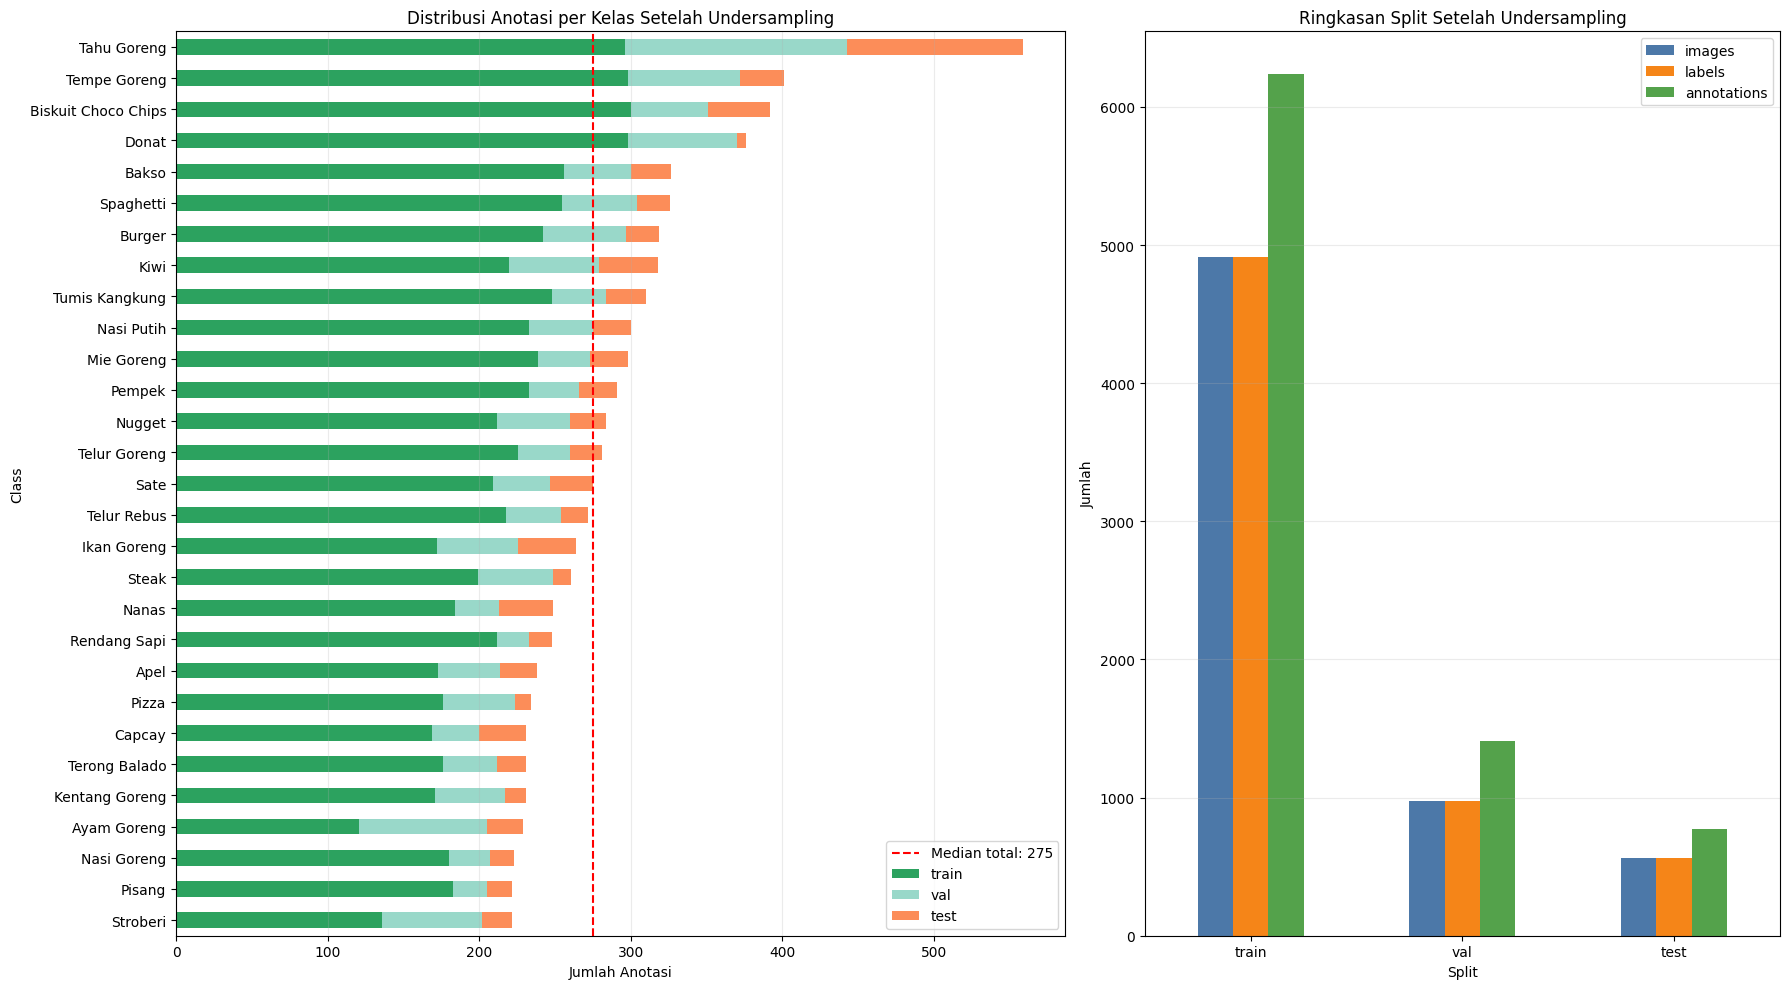

Ringkasan split setelah undersampling:


,images,labels,annotations
split,,,
train,4915,4915,6235
val,978,978,1407
test,562,562,770


Kelas terbesar setelah undersampling:


split,train,val,test,total
class,,,,
Tahu Goreng,296,147,116,559
Tempe Goreng,298,74,29,401
Biskuit Choco Chips,300,51,41,392
Donat,298,72,6,376
Bakso,256,44,27,327
Spaghetti,255,49,22,326
Burger,242,55,22,319
Kiwi,220,59,39,318
Tumis Kangkung,248,36,26,310


Kelas terkecil setelah undersampling:


split,train,val,test,total
class,,,,
Stroberi,136,66,20,222
Pisang,183,22,17,222
Nasi Goreng,180,27,16,223
Ayam Goreng,121,84,24,229
Kentang Goreng,171,46,14,231
Terong Balado,176,36,19,231
Capcay,169,31,31,231
Pizza,176,48,10,234
Apel,173,41,24,238


Plot tersimpan: c:\laragon\www\jivara\dataScience\data_output\docs\post_undersampling_distribution.png


In [143]:
post_undersampling_distribution = count_yolo_annotations_by_split(YOLO_DIR, class_names)
post_undersampling_pivot = (
    post_undersampling_distribution
    .pivot_table(index='class', columns='split', values='annotations', aggfunc='sum', fill_value=0)
    .reindex(columns=['train', 'val', 'test'])
)
post_undersampling_pivot['total'] = post_undersampling_pivot.sum(axis=1)
post_undersampling_pivot = post_undersampling_pivot.sort_values('total')

fig, axes = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [1.4, 1]})
post_undersampling_pivot[['train', 'val', 'test']].plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=['#2ca25f', '#99d8c9', '#fc8d59'],
)
axes[0].axvline(post_undersampling_pivot['total'].median(), color='red', linestyle='--', label=f"Median total: {post_undersampling_pivot['total'].median():.0f}")
axes[0].set_title('Distribusi Anotasi per Kelas Setelah Undersampling')
axes[0].set_xlabel('Jumlah Anotasi')
axes[0].set_ylabel('Class')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.25)

split_counts = []
for split in ['train', 'val', 'test']:
    image_dir = YOLO_DIR / 'images' / split
    label_dir = YOLO_DIR / 'labels' / split
    image_count = sum(
        1 for path in image_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    label_count = len(list(label_dir.glob('*.txt')))
    annotation_count = int(post_undersampling_distribution[post_undersampling_distribution['split'] == split]['annotations'].sum())
    split_counts.append({'split': split, 'images': image_count, 'labels': label_count, 'annotations': annotation_count})

split_counts_df = pd.DataFrame(split_counts).set_index('split')
split_counts_df[['images', 'labels', 'annotations']].plot(kind='bar', ax=axes[1], color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_title('Ringkasan Split Setelah Undersampling')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
post_undersampling_plot_path = DOCS_DIR / 'post_undersampling_distribution.png'
plt.savefig(post_undersampling_plot_path, dpi=160, bbox_inches='tight')
plt.show()

print('Ringkasan split setelah undersampling:')
display(split_counts_df)
print('Kelas terbesar setelah undersampling:')
display(post_undersampling_pivot.sort_values('total', ascending=False).head(10))
print('Kelas terkecil setelah undersampling:')
display(post_undersampling_pivot.sort_values('total').head(10))
print(f'Plot tersimpan: {post_undersampling_plot_path}')


### 5.5 Export ZIP YOLOv11 untuk Roboflow

Cell ini membuat ZIP dataset YOLO final setelah cleanup/undersampling. ZIP berisi `data.yaml`, folder `images`, dan folder `labels`, siap di-upload atau dipakai training YOLOv11.

In [144]:
from zipfile import ZipFile, ZIP_DEFLATED

EXPORT_DIR = OUTPUT_DIR / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
YOLO11_ROBOFLOW_ZIP = EXPORT_DIR / 'yolo11_roboflow_cleaned_dataset.zip'


def export_yolo_zip(yolo_dir, zip_path):
    include_roots = ['data.yaml', 'images', 'labels']
    if zip_path.exists():
        zip_path.unlink()

    file_count = 0
    with ZipFile(zip_path, 'w', compression=ZIP_DEFLATED) as archive:
        for root_name in include_roots:
            source_path = yolo_dir / root_name
            if source_path.is_file():
                archive.write(source_path, arcname=root_name)
                file_count += 1
            elif source_path.is_dir():
                for file_path in source_path.rglob('*'):
                    if file_path.is_file():
                        archive.write(file_path, arcname=file_path.relative_to(yolo_dir))
                        file_count += 1

    return file_count


exported_file_count = export_yolo_zip(YOLO_DIR, YOLO11_ROBOFLOW_ZIP)
print(f'ZIP tersimpan : {YOLO11_ROBOFLOW_ZIP}')
print(f'Total file    : {exported_file_count}')
print(f'Ukuran ZIP    : {YOLO11_ROBOFLOW_ZIP.stat().st_size / (1024 * 1024):.2f} MB')
print(f'Data YAML     : {YOLO_DIR / "data.yaml"}')


ZIP tersimpan : c:\laragon\www\jivara\dataScience\data_output\exports\yolo11_roboflow_cleaned_dataset.zip
Total file    : 12911
Ukuran ZIP    : 708.70 MB
Data YAML     : c:\laragon\www\jivara\dataScience\data_output\yolo_dataset\data.yaml


---
## 6. Validasi Dataset Final

### 6.1 Integrity Check

Memastikan setiap gambar memiliki file label yang sesuai,  
dan semua nilai koordinat dalam label berada dalam rentang valid [0, 1].

In [145]:
def validate_yolo_dataset(yolo_dir, class_count):
    """Validasi integritas dataset YOLO."""
    errors = []
    total_images = 0
    total_labels = 0

    for split in ['train', 'val', 'test']:
        image_dir = yolo_dir / 'images' / split
        label_dir = yolo_dir / 'labels' / split

        image_stems = set(
            p.stem for p in image_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
        label_stems = set(p.stem for p in label_dir.glob('*.txt'))

        orphan_images = image_stems - label_stems
        orphan_labels = label_stems - image_stems
        if orphan_images:
            errors.append(f"[{split}] {len(orphan_images)} gambar tanpa label")
        if orphan_labels:
            errors.append(f"[{split}] {len(orphan_labels)} label tanpa gambar")

        for label_file in label_dir.glob('*.txt'):
            with open(label_file) as fh:
                for line_number, line in enumerate(fh, 1):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        errors.append(f"[{split}] {label_file.name}:{line_number} format salah")
                        continue
                    class_id = int(parts[0])
                    coordinates = [float(v) for v in parts[1:]]
                    if class_id < 0 or class_id >= class_count:
                        errors.append(f"[{split}] {label_file.name}:{line_number} class_id invalid")
                    if not all(0 <= v <= 1 for v in coordinates):
                        errors.append(f"[{split}] {label_file.name}:{line_number} koordinat di luar [0,1]")

        total_images += len(image_stems)
        total_labels += len(label_stems)
        print(f"  {split}: {len(image_stems)} gambar, {len(label_stems)} labels")

    return errors, total_images, total_labels

validation_errors, total_images, total_labels = validate_yolo_dataset(YOLO_DIR, len(class_names))

print(f"\nTotal: {total_images} gambar, {total_labels} labels")
if validation_errors:
    print(f"\nError: {len(validation_errors)}")
    for error in validation_errors[:10]:
        print(f"  {error}")
else:
    print("\nSemua validasi PASSED. Dataset siap untuk training.")

  train: 4915 gambar, 4915 labels
  val: 978 gambar, 978 labels
  test: 562 gambar, 562 labels

Total: 6455 gambar, 6455 labels

Semua validasi PASSED. Dataset siap untuk training.


### 6.2 Visual Spot-Check

Menampilkan sampel gambar acak beserta overlay bounding box  
untuk verifikasi visual bahwa konversi format berjalan dengan benar.

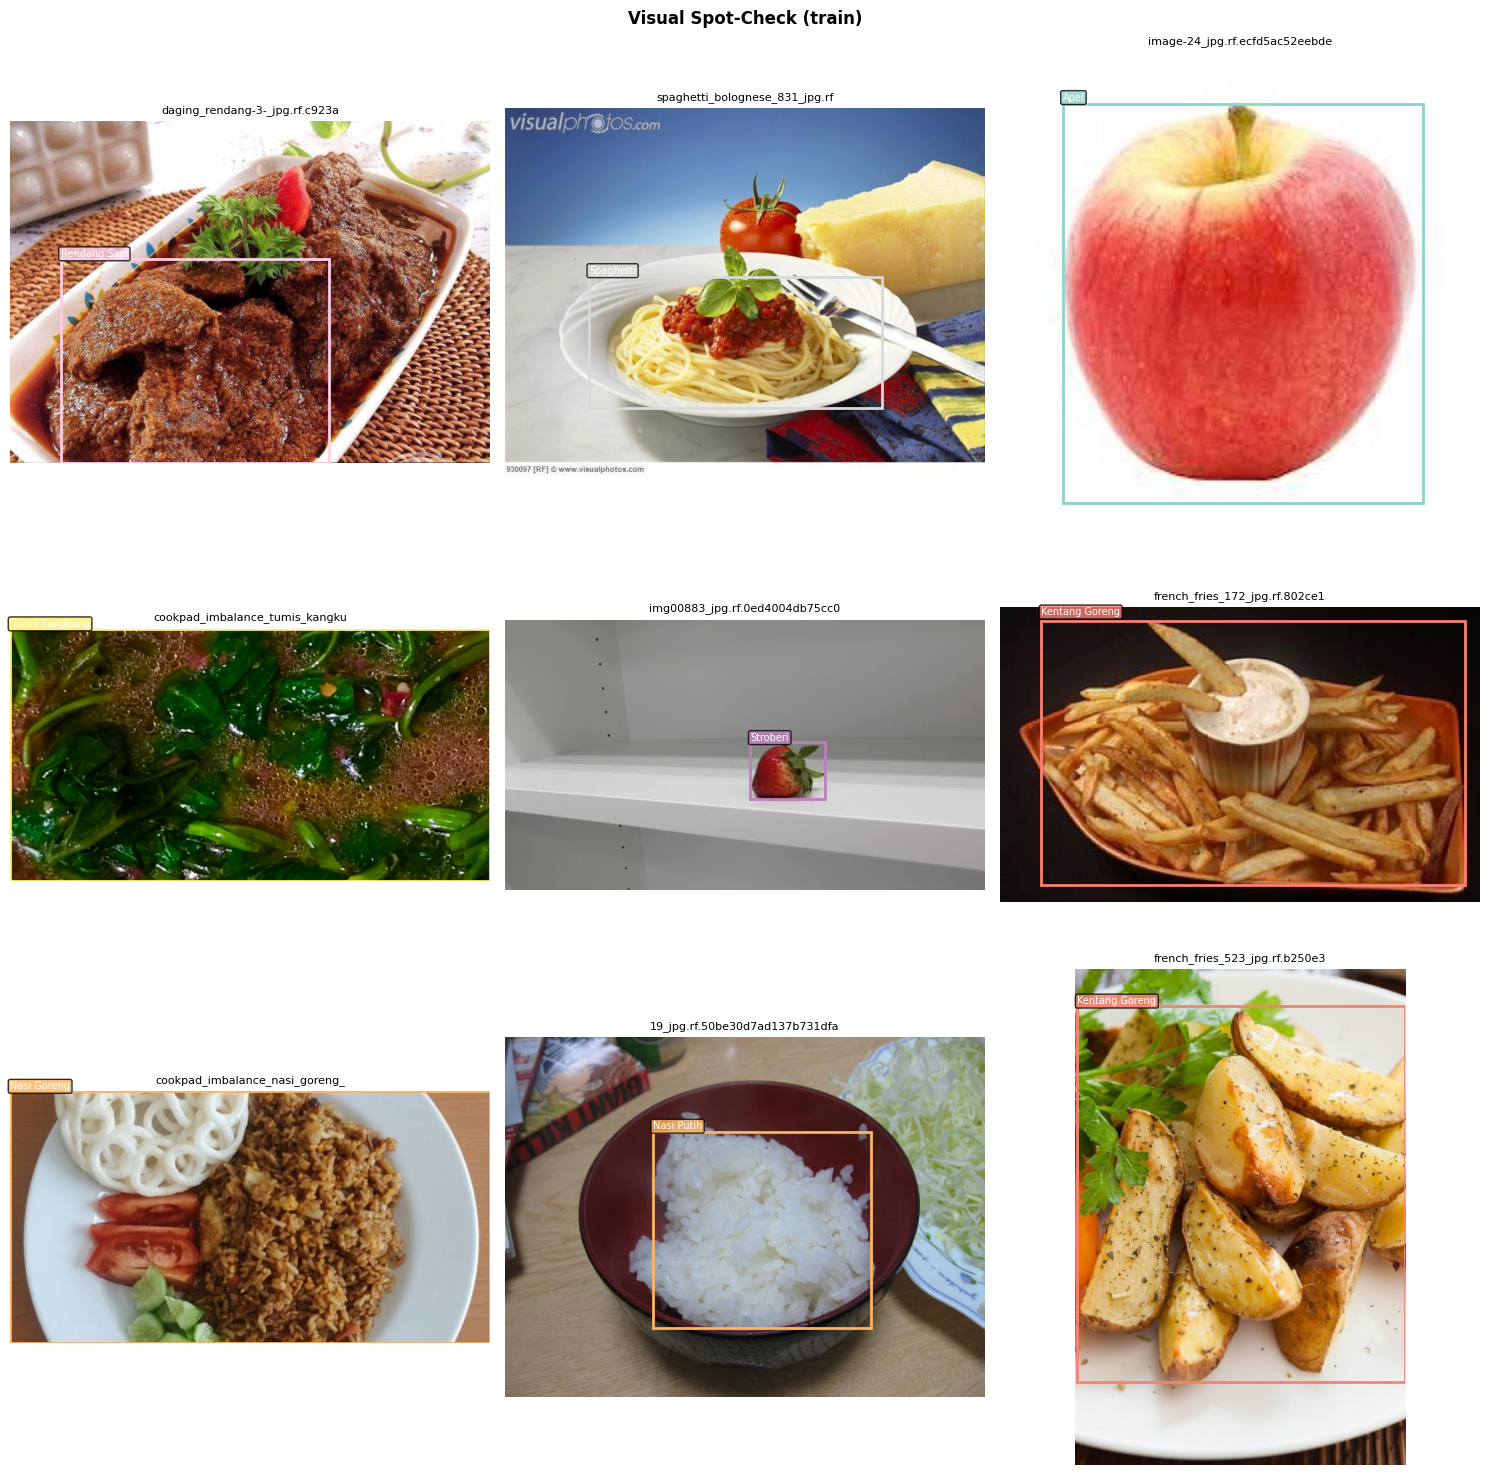

In [146]:
def plot_sample_with_bounding_boxes(yolo_dir, class_names, split='train', sample_count=6):
    """Tampilkan gambar acak dengan overlay bounding box."""
    image_dir = yolo_dir / 'images' / split
    label_dir = yolo_dir / 'labels' / split
    image_files = list(image_dir.glob('*.jpg'))

    np.random.seed(42)
    samples = np.random.choice(image_files, min(sample_count, len(image_files)), replace=False)

    columns = 3
    rows = int(np.ceil(len(samples) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 5 * rows))
    axes = np.array(axes).flatten()
    color_palette = plt.cm.Set3(np.linspace(0, 1, len(class_names)))

    for idx, image_path in enumerate(samples):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_height, img_width = image.shape[:2]
        axes[idx].imshow(image)

        label_path = label_dir / (image_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as fh:
                for line in fh:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_c, y_c, b_w, b_h = [float(v) for v in parts[1:]]

                    x1 = (x_c - b_w / 2) * img_width
                    y1 = (y_c - b_h / 2) * img_height
                    box_w = b_w * img_width
                    box_h = b_h * img_height

                    color = color_palette[class_id % len(color_palette)]
                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    axes[idx].add_patch(rect)
                    axes[idx].text(
                        x1, y1 - 5, class_names[class_id], fontsize=7, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8)
                    )
        axes[idx].set_title(image_path.name[:30], fontsize=8)
        axes[idx].axis('off')

    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Visual Spot-Check ({split})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'docs' / f'visual_spotcheck_{split}.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_with_bounding_boxes(YOLO_DIR, class_names, split='train', sample_count=9)

---
## 6.3 Unduh Gambar Tambahan untuk Kelas Minor

Contoh langkah otomatis: menjalankan skrip `scripts/download_images.py` untuk mengumpulkan gambar tambahan dari Bing,
kemudian menyalinnya ke folder `train_extra` agar dapat diberi anotasi/label sebelum dimasukkan ke dataset training.

Catatan: langkah ini hanya mengumpulkan gambar mentah — Anda tetap perlu memverifikasi kualitas dan membuat anotasi bounding box sebelum digunakan untuk training.

In [147]:
# Cell opsional: downloader tambahan jika suatu saat masih perlu scraping manual.
# Default dibuat False karena data imbalance Cookpad sudah disediakan lokal dan
# sudah digabungkan pada cell 2.1.1.
RUN_OPTIONAL_DOWNLOADER = False

import subprocess

DOWNLOADER = BASE_DIR / 'scripts' / 'download_images.py'
OUT_BASE = BASE_DIR / 'data_mentah' / 'downloads'
TARGET_EXTRA = RAW_DIR / 'train_extra'

try:
    candidates = list(minority_classes.index.astype(str))
except Exception:
    candidates = []

PER_CLASS = 200

if RUN_OPTIONAL_DOWNLOADER and candidates and DOWNLOADER.exists():
    TARGET_EXTRA.mkdir(parents=True, exist_ok=True)
    classes_arg = ','.join(candidates)
    command = [
        'python',
        str(DOWNLOADER),
        '--source',
        'bing',
        '--classes',
        classes_arg,
        '--per-class',
        str(PER_CLASS),
        '--out',
        str(OUT_BASE),
    ]
    print('Menjalankan downloader...')
    print('Command:', ' '.join(command))
    subprocess.run(command, check=True)

    for class_name in candidates:
        source_folder = OUT_BASE / class_name.replace(' ', '_')
        image_files = list(source_folder.glob('*')) if source_folder.exists() else []
        print(f'  {class_name}: {len(image_files)} files (in {source_folder})')

        for image_path in image_files:
            destination = TARGET_EXTRA / image_path.name
            if not destination.exists():
                shutil.copy2(image_path, destination)

    print(f'Copied downloaded images to: {TARGET_EXTRA}')
else:
    print('Downloader opsional dilewati.')
    print('Data imbalance lokal sudah diproses dari:', EXTRA_IMBALANCE_DIR)


Downloader opsional dilewati.
Data imbalance lokal sudah diproses dari: c:\laragon\www\jivara\dataScience\data_mentah\Scraping Image Data Imbalance\cookpad_images untuk roboflow


---
## 7. Laporan Akhir

In [148]:
print("=" * 50)
print("LAPORAN AKHIR DATASET")
print("=" * 50)
print(f"Total gambar : {total_images}")
print(f"Total labels : {total_labels}")
print(f"Jumlah kelas : {len(class_names)}")
print(f"Format       : YOLO TXT (normalized xywh)")
print(f"Output       : {YOLO_DIR}")
print(f"Config       : {YOLO_DIR / 'data.yaml'}")
print(f"\nDataset siap untuk training YOLOv11.")

LAPORAN AKHIR DATASET
Total gambar : 6455
Total labels : 6455
Jumlah kelas : 29
Format       : YOLO TXT (normalized xywh)
Output       : c:\laragon\www\jivara\dataScience\data_output\yolo_dataset
Config       : c:\laragon\www\jivara\dataScience\data_output\yolo_dataset\data.yaml

Dataset siap untuk training YOLOv11.
